# Trias Analysis
This notebook provides a workflow for analyzing codon usage patterns and reproducing the figures in the **Trias** paper.

The following section loads all necessary packages and sets up the environment for plotting, analysis, and model configuration. 

In [1]:
# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.cm import ScalarMappable
import textwrap
import seaborn as sns
# Plot style settings
sns.set_theme(style="white", context="paper", palette="pastel")
# Data and stats libraries
import pandas as pd
import numpy as np
from Bio.Seq import Seq
from scipy.stats import spearmanr, chi2_contingency, mannwhitneyu
from sklearn.metrics import confusion_matrix
from gprofiler import GProfiler
# Deep learning & NLP
from transformers import AutoTokenizer, BartForConditionalGeneration
from datasets import load_dataset
import torch
# Trias-specific imports
from trias.tokenizer import TriasTokenizer
# Custom utility functions
from notebook_utils import *

### Data Loading

Defining paths to the datasets and loading all required data files used throughout the analysis.

> **Note**: Update `DATA_DIR` and `FIGURE_DIR` to match your own setup.

In [15]:
# === Set Data and Figure Directories ===

# Change these paths based on your environment 
DATA_DIR = '../data/' 
FIGURE_DIR = '../figures/'  # optional, if saving figures

# === Load Datasets ===

# Basic metrics
train_data_seq_len_df = pd.read_csv(f"{DATA_DIR}train_data_seq_len.csv")
training_run = pd.read_csv(f"{DATA_DIR}wandb_training_run.csv")

# Codon frequency
codon_table = pd.read_csv(f"{DATA_DIR}codon_table.csv")
srscu_df = codon_table[['codon','srscu_human']].set_index('codon')
srscu_dict = srscu_df.srscu_human.to_dict()
abs_codon_count_dict = codon_table.set_index('codon')['abs_codon_count_human'].to_dict()
rel_codon_count = codon_table.set_index('codon')['rel_codon_count_human']

# Load test dataset
human_testset_df = pd.read_csv(f"{DATA_DIR}human_test_dataset.csv")

max_codons = human_testset_df.protein.map(len).max()
columns = list(range(max_codons))
# Helper function to split into codons with padding
def split_codons(seq):
    return [seq[i:i+3] if i+3 <= len(seq) else None for i in range(0, max_codons * 3, 3)] if isinstance(seq, str) else [None]*max_codons
# Create DataFrames for per codon analysis
true_codon = pd.DataFrame({row['record_id']: split_codons(row['wildtype_seq']) for _, row in human_testset_df.iterrows()}, index=columns).T
predicted_codon = pd.DataFrame({row['record_id']: split_codons(row['trias_greedy_seq']) for _, row in human_testset_df.iterrows()}, index=columns).T
true_codon.index.name = 'record_id'
predicted_codon.index.name = 'record_id'

# Pfam domain annotations from InterPro
interpro_col = [
    'Protein Accession', 'Sequence MD5 digest', 'Sequence length', 'Analysis',
    'Signature accession', 'Signature description', 'Start location', 'Stop location',
    'Score', 'Status', 'Date', 'InterPro annotations - accession',
    'InterPro annotations - description', 'GO annotations', 'Pathways annotations'
]
domain_df = pd.read_csv(f"{DATA_DIR}interpro_output.tsv", sep='\t', header=None, names=interpro_col)
pfam_domain_df = domain_df[domain_df['Analysis'] == 'Pfam']
pfam_domain_df = pfam_domain_df[pfam_domain_df['Score'].astype(float) < 1e-5]
pfam_domain_df["record_id"] = pfam_domain_df["Protein Accession"].str.split("|").str[0]
pfam_domain_df["Start location"] = pfam_domain_df["Start location"].astype(int)
pfam_domain_df["Stop location"] = pfam_domain_df["Stop location"].astype(int)

# GFP variant data
gfp_data = pd.read_csv(f"{DATA_DIR}benchmarks/moderna/gfp.csv")

# GTEx expression data
gtex_data = pd.read_csv(f"{DATA_DIR}GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_median_tpm.gct.gz", sep='\t', skiprows=2)
# Filter out genes with all zero TPMs
tpm_columns = gtex_data.columns[2:]
gtex_data = gtex_data[(gtex_data[tpm_columns] != 0).any(axis=1)]
# Compute median expression per gene
gtex_data['Median'] = gtex_data[tpm_columns].median(axis=1)
# Merge with codon evaluation scores
gene_expression_df = pd.merge(
    human_testset_df,
    gtex_data[['Description', 'Median']],
    left_on='gene_name',
    right_on='Description',
    how='left'
).drop(columns=['Description'])
# Clean up duplicates and missing values
gene_expression_df = (
    gene_expression_df
    .sort_values('Median', ascending=False)
    .drop_duplicates(subset=['gene_name'], keep='first')
    .dropna()
)
# Log-transform median expression
gene_expression_df['Log2Median'] = np.log2(gene_expression_df['Median'] + 1)

### Load Trias Model & Tokenizer

In [3]:
# Load model and tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("lareaulab/Trias", use_fast=True)
model = BartForConditionalGeneration.from_pretrained("lareaulab/Trias").to(device)

# Move model to device and set to eval mode
model = model.to(device)
model.eval();

You passed `num_labels=3` which is incompatible to the `id2label` map of length `1`.


## Figure 1 : Model Overview, Dataset and Training Performance

In [4]:
# Filter out "Unknown" class
train_data_seq_len_df = train_data_seq_len_df[train_data_seq_len_df['class'] != "Unknown"]
train_data_seq_len_df['codon_length'] = train_data_seq_len_df['cds_length'] / 3
# Prepare class sequence counts and sorting
sequence_counts = train_data_seq_len_df['class'].value_counts()
sorted_classes = sequence_counts.index
colors = [
    '#fff8e1', '#ffebcc', '#ffe0b2', '#ffcc99', '#ffb98d',
    '#e6a984', '#d9a28a', '#c9968b', '#b88578', '#a87868'
]
class_color_map = dict(zip(sorted_classes, colors[::-1]))
# Codon lengths DataFrame
codon_lengths = train_data_seq_len_df[['class', 'codon_length']]

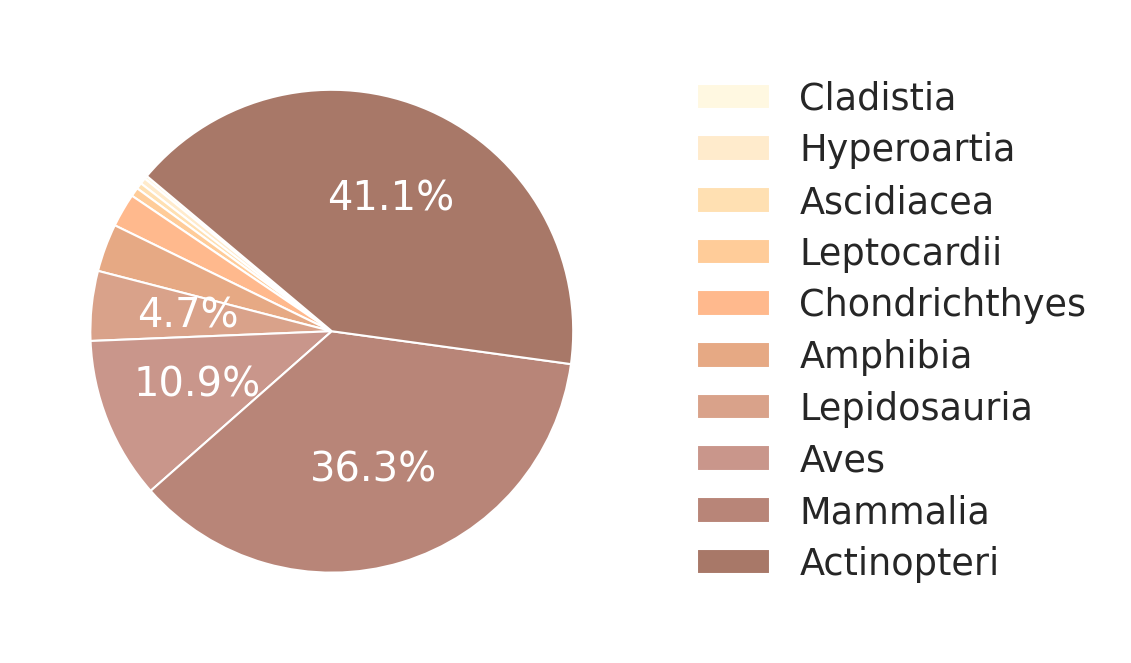

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 2.3), dpi=300)
wedges, texts, autotexts = ax.pie(
    sequence_counts.loc[sorted_classes[::-1]],
    colors=[class_color_map[cls] for cls in sorted_classes[::-1]],
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 4 else '',
    startangle=140,
    wedgeprops={'linewidth': 0.5}
)
for text in autotexts:
    text.set_color('white')
ax.legend(
    labels=sorted_classes[::-1],
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    labelspacing=0.4,
    frameon=False,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR+'figure_1B.pdf', format='pdf')
plt.show()

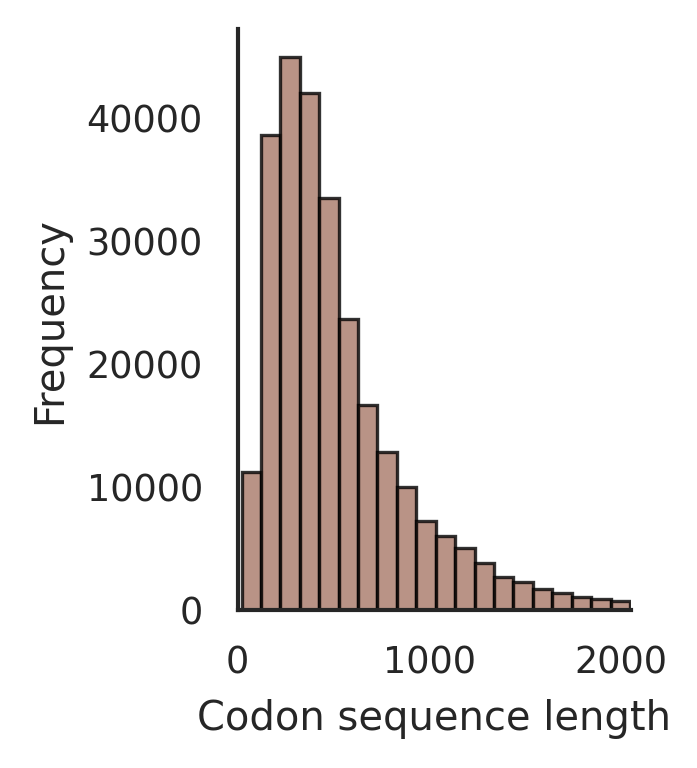

In [8]:
plt.figure(figsize=(2.4, 2.65), dpi=300)
plt.hist(codon_lengths["codon_length"], bins=20, color="#a87868", edgecolor="black", alpha=0.8)
plt.xlabel("Codon sequence length")
plt.ylabel("Frequency")
plt.xlim(0, 2050)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+'figure_1C.pdf', format='pdf')
plt.show()


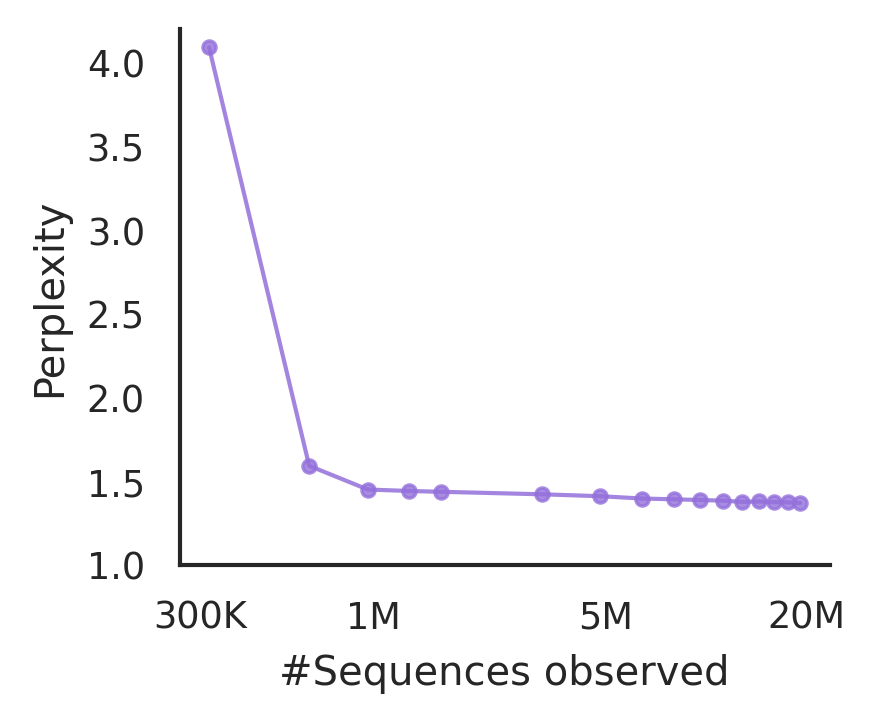

In [9]:
xlabel = np.array(training_run['global_step'].tolist()) * 32
vals = pd.to_numeric(training_run['train_loss'], errors='coerce')
ylabel_eval = np.exp(vals)

plt.figure(figsize=(3., 2.5), dpi=300)
plt.plot(xlabel, ylabel_eval, color="mediumpurple", linewidth=1., alpha=0.85)
plt.scatter(xlabel, ylabel_eval, color="mediumpurple", s=10, alpha=0.8, zorder=3)
plt.xscale('log')
xticks = [300_000, 1_000_000, 5_000_000, 20_000_000]
xtick_labels = ["300K", "1M", "5M", "20M"]
plt.xticks(xticks, xtick_labels)
plt.ylim(1,4.2)
plt.xlabel("#Sequences observed")
plt.ylabel("Perplexity")
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+'figure_1E.pdf', format='pdf')
plt.show()

In [16]:
examples = 20
selected_records = human_testset_df.sample(n=examples, random_state=42)["record_id"].tolist()
df_selected = human_testset_df[human_testset_df["record_id"].isin(selected_records)]
sequences = df_selected.apply(generate_prompt_from_dataset, axis=1).tolist()

labels_embedding = generate_labels(df_selected, examples=examples, srscu_df=srscu_df.srscu_human, max_length_data=2046, level="token")

encoder_embeddings_tokens = extract_embeddings(model, tokenizer, sequences, layer=-1, exclude_first_n_tokens=1, bart_state="encoder", level="token")

In [ ]:
reduced_dim = reduce_dimensionality(encoder_embeddings_tokens, method='tsne', perplexity=20, n_components=2, n_iter=1_000)

In [ ]:
# Species, Amino Acid, Codon, Polarity, Charge, Volume, Chemical, Hydropathy, GC content, Properties, sRSCU
plot_embeddings(reduced_dim, labels_embedding, label_name="Properties", figure_name=FIGURE_DIR+"figure_1F.pdf")

In [19]:
# select small human protein and plot attention map
small_protein_row = human_testset_df[human_testset_df['gene_name'] == "COX7B2"].iloc[0]
small_protein_prompt = generate_prompt_from_dataset(small_protein_row)

In [ ]:
# Plot cross-attention for all heads and save each map
plot_attention_weights(model, tokenizer, small_protein_prompt, device=device, head=2, attention_type="cross", figure_name=FIGURE_DIR+"figure_1G_supp2.pdf")

In [ ]:
# Flatten the DataFrames
true_codons = true_codon.values.flatten()  # Convert to 1D array
pred_codons = predicted_codon.values.flatten()  # Convert to 1D array
# Remove None or NaN values
mask = ~pd.isnull(true_codons) & ~pd.isnull(pred_codons)
true_codons = true_codons[mask]
pred_codons = pred_codons[mask]
# Find the most frequent codon for each amino acid
most_frequent_codons = {}
for aa, codon_group in aa_to_codon.items():
    freq_values = rel_codon_count[codon_group]
    most_frequent_codon = freq_values.astype(float).idxmax()
    most_frequent_codons[aa] = most_frequent_codon
# Flatten the aa_to_codon to create an ordered codon list
sorted_codon_labels = [codon for codons in aa_to_codon.values() for codon in codons]
# Filter out codons not present in true_codons or pred_codons (ensure all are present in the sorted list)
codon_labels_present = np.unique(np.concatenate((true_codons, pred_codons)))
sorted_codon_labels = [codon for codon in sorted_codon_labels if codon in codon_labels_present]
# Create the confusion matrix
conf_matrix = confusion_matrix(true_codons, pred_codons, labels=sorted_codon_labels)
# Normalize the confusion matrix per amino acid
conf_matrix_normalized = np.zeros_like(conf_matrix, dtype=float)

for aa, codon_group in aa_to_codon.items():
    # Get the indices for the synonymous codons of this amino acid
    codon_indices = [sorted_codon_labels.index(codon) for codon in codon_group if codon in sorted_codon_labels]
    if codon_indices:
        # Extract the submatrix for this amino acid group
        submatrix = conf_matrix[np.ix_(codon_indices, codon_indices)]
        # Normalize each row of the submatrix to sum to 100 (percentage within this amino acid)
        row_sums = submatrix.sum(axis=1, keepdims=True)
        normalized_submatrix = np.divide(submatrix, row_sums, where=row_sums != 0) * 100  # Avoid division by zero
        # Insert the normalized submatrix back into the overall matrix
        for i, idx1 in enumerate(codon_indices):
            for j, idx2 in enumerate(codon_indices):
                conf_matrix_normalized[idx1, idx2] = normalized_submatrix[i, j]


In [ ]:
# Plot the confusion matrix as a heatmap 
plt.figure(figsize=(8, 8), dpi=300)
# Custom label formatter to bold the most frequent codon
def bold_most_frequent_label(label):
    for aa, codon in most_frequent_codons.items():
        if label == codon:
            return f"$\\bf{{{label}}}$" 
    return label

# Format the codon labels with the custom formatter
formatted_xlabels = [bold_most_frequent_label(label) for label in sorted_codon_labels]
formatted_ylabels = [bold_most_frequent_label(label) for label in sorted_codon_labels]

ax = sns.heatmap(conf_matrix_normalized, xticklabels=formatted_xlabels, yticklabels=formatted_ylabels, cmap="Purples", annot=False, cbar=False)
plt.xlabel("Predicted Codons")
plt.ylabel("True Codons")
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.tight_layout()
# Draw black boxes around synonymous codon groups, dashed lines, and annotate amino acids
for aa, codon_group in aa_to_codon.items():
    # Find the start and end index of each synonymous group in sorted_codon_labels
    codon_indices = [sorted_codon_labels.index(codon) for codon in codon_group if codon in sorted_codon_labels]
    if codon_indices:
        start = min(codon_indices)
        end = max(codon_indices)
        # Add a rectangle around this codon group
        ax.add_patch(patches.Rectangle((start, start), end-start+1, end-start+1, fill=False, edgecolor='black', lw=0.5))
        # Add dashed lines to x-axis (codon labels) and y-axis (codon labels)
        plt.axhline(y=start, color='black', linestyle='--', linewidth=.1)
        plt.axvline(x=start, color='black', linestyle='--', linewidth=.1)
        # Annotate the upper-right corner of the rectangle with the amino acid
        ax.text(end + 1.6, start + 0.5, aa, color='black', fontsize=10, ha='center', va='center')

# Show the heatmap
plt.savefig(FIGURE_DIR+"figure_S1.pdf", format="pdf")
plt.show()


In [ ]:
true_aa = np.array([codon_to_aa[c] for c in true_codons])
pred_aa = np.array([codon_to_aa[c] for c in pred_codons])

wrong_aa = np.sum(true_aa != pred_aa)
total = len(true_aa)

print("Wrong amino acid predictions:", wrong_aa)
print("Fraction wrong:", wrong_aa / total)

In [ ]:
mutational_distances = []
mismatch_positions = []
mutation_types = []

for t_codon, p_codon in zip(true_codons, pred_codons):
    distance, mismatch_position = calculate_mutational_distance(t_codon, p_codon)
    if distance is not None:
        mutational_distances.append(distance)
        mismatch_positions.extend(mismatch_position)
        mutation_types.extend(classify_mutation(t_codon, p_codon))

In [ ]:
# Helper function to add counts on top of the bars with 'N=' before each count
def annotate_bars(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'N={int(height)}', (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                        textcoords='offset points')

fig, axes = plt.subplots(1, 2, figsize=(4, 2.2), dpi=300)
ax = sns.histplot(mutational_distances, bins=[0.5, 1.5, 2.5, 3.5], kde=False, ax=axes[0], color='mediumpurple')
axes[0].set_xticks([1, 2, 3])
axes[0].set_xlabel('Mutational Distance')
axes[0].set_ylabel('Count')

ax = sns.histplot(mismatch_positions, bins=[0.5, 1.5, 2.5, 3.5], kde=False, ax=axes[1], color='mediumpurple')
axes[1].set_xticks([1, 2, 3])
axes[1].set_xlabel('Mismatch Position')
axes[1].set_ylabel('Count')

axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_S2_A_B.pdf", format="pdf")
plt.show()


## Figure 2 : Sequence-Level Analysis

In [ ]:
# Select a few examples of genes with low predicted sRSCU scores for further analysis
annotation_dict = {'NM_003596.4': '*', 'NM_001023.4': '‡', 'NM_080740.5': '†', 'NM_018723.4': '.*'} 
# Determine threshold for bimodal distribution of predicted sRSCU scores using Gaussian Mixture Model
srscu_threshold_pred = gmm_cutoff(human_testset_df['srscu_greedy'].tolist()).round(2)
low_srscu_genes = human_testset_df[human_testset_df['srscu_greedy'] <= srscu_threshold_pred]['record_id'].tolist()


In [ ]:
scatter_with_marginals(human_testset_df, 'srscu_wildtype', 'srscu_greedy', 'figure_2A_1', 'Wild-type sequences', 'Generated sequences', figure_dir=FIGURE_DIR, highlighted_genes=low_srscu_genes, annotation_dict=annotation_dict, xlim=(0.7, 1), ylim=(0.7, 1))
scatter_with_marginals(human_testset_df, 'gc_3rd_wildtype', 'gc_3rd_greedy', 'figure_2A_2', 'Wild-type sequences', 'Generated sequences', figure_dir=FIGURE_DIR, highlighted_genes=low_srscu_genes, annotation_dict=annotation_dict, xlim=(-1, 101), ylim=(-1, 101))
scatter_with_marginals(human_testset_df, 'mfe_wildtype', 'mfe_greedy', 'figure_2A_3', 'Wild-type sequences', 'Generated sequences', figure_dir=FIGURE_DIR, highlighted_genes=low_srscu_genes, annotation_dict=annotation_dict, xlim=(-2.2, 0), ylim=(-2.2, 0))

In [ ]:
# random_urc, random_bfc, bayes, nuc099, beam20
color = 'mediumpurple' 
scatter_with_marginals(human_testset_df, 'srscu_wildtype', 'srscu_beam20', 'figure_2A_supp10', 'Wild-type sequences', 'Generated sequences', figure_dir=FIGURE_DIR, xlim=(0.7, 1), ylim=(0.7, 1), color=color)
scatter_with_marginals(human_testset_df, 'gc_3rd_wildtype', 'gc_3rd_beam20', 'figure_2A_supp11', 'Wild-type sequences', 'Generated sequences', figure_dir=FIGURE_DIR, xlim=(-1, 101), ylim=(-1, 101), color=color)
scatter_with_marginals(human_testset_df, 'mfe_wildtype', 'mfe_beam20', 'figure_2A_supp12', 'Wild-type sequences', 'Generated sequences', figure_dir=FIGURE_DIR, xlim=(-2.2, 0), ylim=(-2.2, 0), color=color)

In [ ]:
import itertools

values_to_compare = ['acc_random_urc', 'acc_random_bfc', 'acc_bayes', 'acc_trias_nuc099', 'acc_trias_greedy', 'acc_trias_beam20']

for col1, col2 in itertools.combinations(values_to_compare, 2):
    stat, p = mannwhitneyu(human_testset_df[col1], human_testset_df[col2], alternative='two-sided')
    print(f"{col1} vs {col2} -> U={stat:.3f}, p={p:.3e}")

In [ ]:
values_to_compare = ['acc_random_urc', 'acc_random_bfc', 'acc_bayes', 'acc_trias_nuc099', 'acc_trias_beam20', 'acc_trias_greedy']
df_melted = human_testset_df.melt(id_vars=['gene_name'], value_vars=values_to_compare, 
                    var_name='Model', value_name='Accuracy')
df_melted['Model'] = df_melted['Model'].map({values_to_compare[0]: 'Random \n(URC)', values_to_compare[1]: 'Random \n(BFC)',
                                            values_to_compare[2]: 'Baseline', values_to_compare[3]: 'Trias \n(nucleus)',
                                            values_to_compare[4]: 'Trias \n(beam)', values_to_compare[5]: 'Trias \n(greedy)'})

plt.figure(figsize=(2.3,5.1), dpi=300)
ax = sns.violinplot(x='Accuracy', y='Model', hue='Model', data=df_melted, palette=['0.7', '0.6', 'g', 'mediumpurple', 'mediumpurple',  'mediumpurple'], alpha=0.6)

ax.set_xlim(0,1)
ax.set_ylabel('')  # Remove y-axis label
ax.set_xlabel('Codon similarity \nto wild-type')
ax.axvline(0.5, linestyle='--', color='0.2', linewidth=0.5)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_2B.pdf", format="pdf")
plt.show()

In [ ]:
df_melted.groupby("Model")["Accuracy"].mean()

In [ ]:
protein_ids = annotation_dict.keys()
selected_rows = human_testset_df[human_testset_df['record_id'].isin(protein_ids)]
selected_rows.loc[:, 'record_id'] = pd.Categorical(selected_rows['record_id'], categories=protein_ids, ordered=True)
selected_rows = selected_rows.sort_values('record_id').reset_index(drop=True)
window_size = 18
true_min_max = []
predicted_min_max = []
for i in range(len(protein_ids)): 
    true_min_max.append(calculate_min_max(seq_to_codons(selected_rows.wildtype_seq[i]), abs_codon_count_dict, codon_to_aa, window_size))
    predicted_min_max.append(calculate_min_max(seq_to_codons(selected_rows.trias_greedy_seq[i]), abs_codon_count_dict, codon_to_aa, window_size))


In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(5., 4.5), dpi=300)
axes = axes.flatten()
# Gene names and their categories
gene_info = {
    'NM_018723.4': {'name': 'RBFOX1', 'category': 'Low sRSCU'},
    'NM_080740.5': {'name': 'ZNF280A', 'category': 'Low sRSCU'},
    'NM_003596.4': {'name': 'TPST1', 'category': 'High sRSCU'},
    'NM_001023.4': {'name': 'RPS20', 'category': 'High sRSCU'},
}
# Create each subplot
for idx, (gene_id, gene_data) in enumerate(zip(protein_ids, zip(true_min_max, predicted_min_max))):
    ax = axes[idx]
    # Extract the Min/Max values
    true_values = gene_data[0]
    predicted_values = gene_data[1]
    codon_indices = list(range(len(true_values)))
    category = gene_info[gene_id]['category']
    color = 'mediumorchid' if category == 'Low sRSCU' else 'rebeccapurple'
    # Plot true and predicted Min/Max values
    ax.plot(codon_indices, true_values, label='Wild-type', color='peru', alpha=0.75)
    ax.plot(codon_indices, predicted_values, label='Trias', color=color, alpha=0.75)
    # Add title and labels
    gene_name = gene_info[gene_id]['name']
    ax.set_title(f"{gene_name}")
    if idx == 3: ax.set_xlabel("Codon index")  # Only for bottom row
    ax.set_ylabel("% MinMax")
    ax.set_ylim(-104, 104)
    ax.set_xlim(0,codon_indices[-1])
    ax.axhline(0, color='0.5', linestyle='--', linewidth=0.8)

handles, labels = axes[0].get_legend_handles_labels()
sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIGURE_DIR+"figure_2C.pdf", format="pdf")
plt.show()

In [ ]:
# Euclidean distance between true and predicted Min/Max values for each gene, normalized by sequence length
print(euclidean(true_min_max[0], predicted_min_max[0]) / len(true_min_max[0]))
print(euclidean(true_min_max[1], predicted_min_max[1]) / len(true_min_max[1]))
print(euclidean(true_min_max[2], predicted_min_max[2]) / len(true_min_max[2]))
print(euclidean(true_min_max[3], predicted_min_max[3]) / len(true_min_max[3]))

In [ ]:
def add_correlations(ax, x, y, pos_x=0.05, pos_y=0.95):
    # Calculate correlations
    spearman_r, spearman_p = spearmanr(x, y, nan_policy='omit')    
    # Add text with correlations
    ax.text(pos_x, pos_y, f'Spearman ρ = {spearman_r:.2f}', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='top',
            linespacing=1.2)
    print(spearman_p)

In [ ]:
# srscu_greedy vs Log2Median
# acc_trias_greedy vs srscu_wildtype
# acc_trias_greedy vs Log2Median
# srscu_wildtype vs Log2Median
# label names: # sRSCU (generated sequences), Codon similarity to wild-type, sRSCU (wild-type sequences), Log2(median \ngene expression)
xlabel = 'srscu_greedy'; xlabel_name = 'sRSCU (generated sequences)' 
ylabel = 'Log2Median' ; ylabel_name = 'Log2(median \ngene expression)'
fig, axs = plt.subplots(1, 1, figsize=(2.85, 2.19), dpi=300) # (2.85, 2.19) and (2.9, 2.8) 
sns.regplot(ax=axs, x=xlabel, y=ylabel, data=gene_expression_df, scatter_kws={"s": 10, "alpha":0.5}, line_kws={"color": "indigo"}, color='mediumpurple')
axs.set_xlabel(xlabel_name)
axs.set_ylabel(ylabel_name)
add_correlations(axs, gene_expression_df[xlabel], gene_expression_df[ylabel])
axs.set_ylim(-.5, 11.3)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_2E.pdf", format="pdf")
plt.show()


In [30]:
high_srscu_genes = human_testset_df[human_testset_df['srscu_greedy'] > srscu_threshold_pred]['gene_name'].tolist()
low_srscu_genes = human_testset_df[human_testset_df['srscu_greedy'] <= srscu_threshold_pred]['gene_name'].tolist()
all_human_test_genes = list(set(human_testset_df['gene_name'].tolist()))
# Perform GO enrichment analysis
gp = GProfiler(return_dataframe=True)
go_results = gp.profile(
    organism='hsapiens', 
    no_evidences=False,
    query=low_srscu_genes, #high_srscu_genes, low_srscu_genes
    background=all_human_test_genes,
    sources=['GO:BP', 'GO:CC', 'GO:MF'], # 'GO:BP', 'GO:CC', 'GO:MF',
    significance_threshold_method='bonferroni', 
    user_threshold=0.05,
)
go_results = go_results.sort_values(by='p_value')
go_results['log_p_value'] = -np.log10(go_results['p_value'])
go_results['term_with_source'] = go_results.apply(lambda row: f"{row['name']} ({row['source']})", axis=1)
go_results["GeneRatio"] = go_results["intersection_size"] / go_results["query_size"]
# Apply wrapping to the 'name' column (you can adjust width to your liking)
go_results["term_label"] = go_results.apply(
    lambda row: textwrap.fill(row["term_with_source"], width=17) + f" - n={row['intersection_size']}",
    axis=1,)
go_results = go_results.sort_values("GeneRatio", ascending=False)

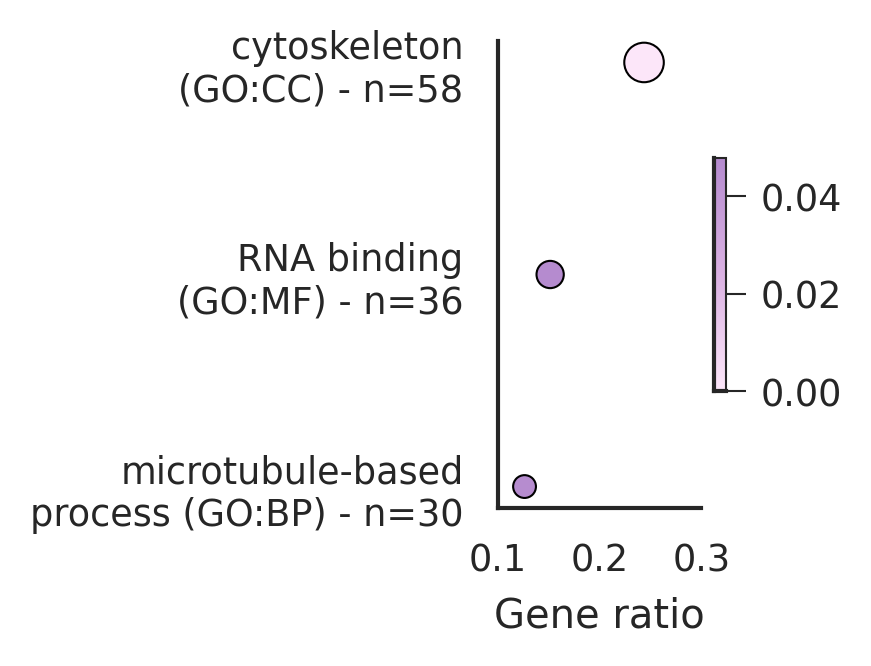

In [31]:
mediumorchid_cmap = mcolors.LinearSegmentedColormap.from_list(
    "mediumorchid", ["#fce6f9", "#dab1e2", "#b58bcf"]
)

fig, ax = plt.subplots(figsize=(2.8, 2.3), dpi=300)
dot = sns.scatterplot(
    data=go_results,
    x="GeneRatio",
    y="term_label", 
    size="intersection_size",
    hue="p_value",
    palette=mediumorchid_cmap,
    sizes=(30, 90),
    edgecolor="black",
    linewidth=0.5,
    legend="brief",
    marker="o",
    ax=ax 
)

dot.legend_.remove()
# Create ScalarMappable with same colormap and normalization
norm = mcolors.Normalize(0., go_results["p_value"].max())
sm = ScalarMappable(cmap=mediumorchid_cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.5)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(width=0.5)
ax.set_xlabel("Gene ratio")
ax.set_xlim(0.1,0.3)
ax.set_ylabel("") # Molecular function
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_DIR + "figure_2F.pdf", format="pdf")
plt.show()

In [ ]:
gc_srscu_df = codon_table[['codon', 'srscu_human']].copy()
gc_srscu_df['amino acid'] = gc_srscu_df["codon"].apply(lambda x: codon_to_aa[x])
gc_srscu_df["gc content"] = gc_srscu_df["codon"].apply(calculate_gc_content)
unique_aa = [aa for aa in gc_srscu_df["amino acid"].unique() if aa not in ["Met", "Trp", "Stop"]]

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(10.2,5), sharex=True, sharey=True, dpi=300)
axes = axes.flatten()
# Plot each amino acid's codons
for i, aa in enumerate(unique_aa):
    ax = axes[i]
    aa_data = gc_srscu_df[gc_srscu_df["amino acid"] == aa]
    sns.scatterplot(
        data=aa_data,
        x="srscu",
        y="gc content",
        color='orange',
        alpha=0.75,
        ax=ax,
        s=30
    )
    ax.set_xlim(0., 1.1)
    ax.set_ylim(-4, 104)
    ax.set_title(aa)
    ax.set_ylabel("GC content [%]")
    ax.set_xlabel("sRSCU")
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_S5.pdf", format="pdf")
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(2.5, 2), dpi=300)

sns.scatterplot(
    data=gc_srscu_df,
    x="srscu",
    y="gc content",
    color='orange',
    alpha=0.75,
    s=30,
    ax=ax
)

ax.set_xlim(0., 1.1)
ax.set_ylim(-4, 104)
ax.set_ylabel("GC content [%]")
ax.set_xlabel("sRSCU")

sns.despine()
plt.tight_layout()
plt.show()


# Figure 3 : Codon-Level Analysis

In [ ]:
aa_to_srscu = {}
for codon, aa in codon_to_aa.items():
    if codon in srscu_dict:
        if aa not in aa_to_srscu:
            aa_to_srscu[aa] = []
        aa_to_srscu[aa].append(srscu_dict[codon])

sorted_aa = sorted(aa_to_srscu.keys(), key=lambda aa: len(aa_to_srscu[aa]))
aa_positions = {aa: i for i, aa in enumerate(sorted_aa)}

In [ ]:
# Plot each amino acid's corresponding SRSCU values
plt.figure(figsize=(2.7, 3.7),dpi=300)
for aa, values in aa_to_srscu.items():
    plt.scatter(values, [aa_positions[aa]] * len(values), color='peru', alpha=.8)

plt.yticks(range(len(sorted_aa)), sorted_aa)
plt.axvline(0.8, color='0.5', linewidth=0.5, linestyle="--")
plt.xlim(0,1.05)
plt.xlabel("sRSCU")
plt.ylabel("Amino acid")
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_3A.pdf", format="pdf")
plt.show()


In [ ]:
count = (~predicted_codon.isna() & ~true_codon.isna()).astype(int)
accuracy = (predicted_codon==true_codon).astype(int)
amino_acid = true_codon.replace(codon_to_aa)
seq_lens = count.sum(axis=1)
true_codon_srscu = true_codon.applymap(lambda codon: srscu_dict.get(codon, None))  
pred_codon_srscu = predicted_codon.applymap(lambda codon: srscu_dict.get(codon, None))  

In [ ]:
SELECTED_AMINO_ACIDS = ["Gln", "His", "Ile", "Ala", "Gly", "Pro", "Val",
                        "Thr", "Arg", "Ser", "Leu"]

SRSCU_THRESHOLD_WT = 0.8

CATEGORY_COMMON_CORRECT = "Correctly predicted \ncommon codon"
CATEGORY_COMMON_MISCLASS = "Misclassified as \nrare codon"
CATEGORY_RARE_CORRECT = "Correctly predicted \nrare codon"
CATEGORY_RARE_MISCLASS = "Misclassified as \ncommon codon"

COMMON_CATEGORIES = [CATEGORY_COMMON_CORRECT, CATEGORY_COMMON_MISCLASS]
RARE_CATEGORIES = [CATEGORY_RARE_CORRECT, CATEGORY_RARE_MISCLASS]
ALL_CATEGORIES = COMMON_CATEGORIES + RARE_CATEGORIES

# Palette — consistent with D/E/F bar plots in the current paper
CATEGORY_COLORS = {
    CATEGORY_RARE_CORRECT:    "#e68ae6",
    CATEGORY_RARE_MISCLASS:   "plum",
    CATEGORY_COMMON_MISCLASS: "rebeccapurple",
    CATEGORY_COMMON_CORRECT: "indigo",
}

In [ ]:
# Create mask for if codon is in domain or not
domain_mask_df = true_codon.copy().astype(object)
domain_mask_df[:] = None
domain_mask_df[count == 1] = 0 

for record_id, group in pfam_domain_df.groupby("record_id"):
    if record_id in domain_mask_df.index:
        for _, row in group.iterrows():
            start = row["Start location"] - 1  # Convert to 0-based
            stop = row["Stop location"] - 1
            domain_mask_df.iloc[domain_mask_df.index.get_loc(record_id), start:stop] = 1 
            
# Generate a position array that repeats for each sequence
codon_index = np.tile(np.arange(max_codons), len(amino_acid))
protein_len = count.sum(axis=1).loc[:].repeat(max_codons)
distance_to_stop_codon = protein_len-codon_index
distance_to_stop_codon = distance_to_stop_codon.where(distance_to_stop_codon >= 0, None)

rare_codon_analysis_df = pd.DataFrame([[categorize_codon(wt, pred, SRSCU_THRESHOLD_WT) 
      for wt, pred in zip(wt_row, pred_row)]
      for wt_row, pred_row in zip(true_codon_srscu.values, pred_codon_srscu.values)],
      index=human_testset_df.record_id,
      columns=true_codon_srscu.columns
)
rare_codon_analysis_df.columns = range(rare_codon_analysis_df.shape[1])

# Stack the data and include Position column
codon_level_analysis_df = pd.DataFrame({
    'Codon Index': codon_index,
    'Distance to Stop': distance_to_stop_codon.to_numpy(),
    'Amino Acid': amino_acid.stack(dropna=False),
    'Predicted Codon': predicted_codon.stack(dropna=False),
    'True Codon': true_codon.stack(dropna=False),
    'Predicted sRSCU': pred_codon_srscu.stack(dropna=False),
    'True sRSCU': true_codon_srscu.stack(dropna=False),
    'Accuracy': accuracy.stack(dropna=False),
    'Count': count.stack(dropna=False),
    'Domain': domain_mask_df.stack(dropna=False),
}).reset_index(drop=True)

codon_level_analysis_df['Codon Category'] = rare_codon_analysis_df.stack(dropna=False).reset_index(drop=True)
codon_level_analysis_df["RSCU Difference"] = codon_level_analysis_df["Predicted sRSCU"] - codon_level_analysis_df["True sRSCU"]

codon_level_analysis_df["Sequence Length"] = np.repeat(seq_lens.values, max_codons)[:len(codon_level_analysis_df)]  
codon_level_analysis_df = codon_level_analysis_df.dropna(subset=['True Codon']).reset_index(drop=True)

codon_category_order = ["Correctly predicted \ncommon codon", "Misclassified as \nrare codon",
                        "Correctly predicted \nrare codon", "Misclassified as \ncommon codon"]
codon_level_analysis_df["Codon Category"] = pd.Categorical(codon_level_analysis_df["Codon Category"], categories=codon_category_order, ordered=True)

codon_level_analysis_df["Relative Codon Position"] = ((codon_level_analysis_df["Codon Index"]+1) / codon_level_analysis_df["Sequence Length"]) * 100

In [ ]:
codon_level_analysis_df = codon_level_analysis_df[codon_level_analysis_df["Amino Acid"].isin(SELECTED_AMINO_ACIDS)]

In [ ]:
category_counts = codon_level_analysis_df["Codon Category"].value_counts()
base_colors = ["#e68ae6", "plum", "rebeccapurple", "indigo"]
pastel_colors = [mcolors.to_rgba(color, alpha=0.6) for color in CATEGORY_COLORS.values()]
plt.figure(figsize=(3., 3.), dpi=300)
plt.pie(
    category_counts.sort_values(),
    labels=None,
    autopct=None, #'%1.f%%',  
    startangle=90,
    colors=pastel_colors,
    wedgeprops={'edgecolor': 'white'},
    textprops={'color': 'white', 'fontsize': 7}
)
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_3B.pdf", format="pdf")
plt.show()
category_counts

In [ ]:
# Build codon_pair_df
codon_pair_df = extract_codon_pairs(codon_level_analysis_df)
codon_pair_df = codon_pair_df.pivot(index="Codon Pair", columns="Codon Category", values="Count").fillna(0)
codon_pair_df["First Codon"] = codon_pair_df.index.str.split("-").str[0]
codon_pair_df["Second Codon"] = codon_pair_df.index.str.split("-").str[1]
codon_pair_df["First AA"] = codon_pair_df["First Codon"].map(codon_to_aa)
codon_pair_df["Second AA"] = codon_pair_df["Second Codon"].map(codon_to_aa)
codon_pair_df["First Codon Label"] = codon_pair_df["First Codon"].map(lambda codon: "Rare" if srscu_dict.get(codon, 0) < SRSCU_THRESHOLD_WT else "Common")
codon_pair_df["Second Codon Label"] = codon_pair_df["Second Codon"].map(lambda codon: "Rare" if srscu_dict.get(codon, 0) < SRSCU_THRESHOLD_WT else "Common")
codon_pair_df = codon_pair_df[codon_pair_df["First AA"].isin(SELECTED_AMINO_ACIDS)]
codon_pair_df = codon_pair_df[codon_pair_df["Second AA"].isin(SELECTED_AMINO_ACIDS)]

In [ ]:
agg_dict = {
    'Correctly predicted \ncommon codon': 'sum', 
    'Misclassified as \nrare codon': 'sum', 
    'Correctly predicted \nrare codon': 'sum', 
    'Misclassified as \ncommon codon': 'sum', 
    'Second Codon': 'sum', 
    'First AA': 'first',
    'Second AA': 'sum', 
    'First Codon Label': 'first',  
    'Second Codon Label': 'sum',    
}

In [ ]:
label_groupby = 'First AA' # First Codon, First AA, First Codon Label
observed_counts_common = codon_pair_df.groupby(label_groupby).agg(agg_dict).iloc[:,:2]
observed_counts_rare = codon_pair_df.groupby(label_groupby).agg(agg_dict).iloc[:,2:4]

_, p_common, _, expected_counts_common = chi2_contingency(observed_counts_common)
_, p_rare, _, expected_counts_rare = chi2_contingency(observed_counts_rare)

total_common = observed_counts_common.sum().sum()
residuals_common = (observed_counts_common - expected_counts_common) / np.sqrt(expected_counts_common)
residuals_rare = (observed_counts_rare - expected_counts_rare) / np.sqrt(expected_counts_rare)


In [ ]:
residuals_rare_long = residuals_rare.reset_index().melt(
    id_vars=label_groupby,
    var_name="Codon Category",
    value_name="Residual"
)
residuals_common_long = residuals_common.reset_index().melt(
    id_vars=label_groupby,
    var_name="Codon Category",
    value_name="Residual"
)

In [ ]:
plt.figure(figsize=(3., 1.7), dpi=300) # Codon label: 3x1.7, AA: 7, Codon: 11x2
ax = sns.barplot(
    data=residuals_common_long,
    x=label_groupby,
    y="Residual",
    hue="Codon Category",
    palette=["mediumpurple", "0.92"], 
    edgecolor="0.2",
    linewidth=0.4,
    alpha=0.7,
    legend=False,
)

# Color x-tick labels gray if codon is rare
#for tick_label in ax.get_xticklabels():
#    codon = tick_label.get_text()
#    if srscu_dict.get(codon, 0) < SRSCU_THRESHOLD_WT:
#        tick_label.set_color("0.7")
#    else:
#        tick_label.set_color("black")

ax.tick_params(axis='x', rotation=0) # 0, 45
ax.set_ylim(-50,50) # 100, 30
ax.axhline(0, color="0.3", linestyle="-", linewidth=0.5)
ax.set_ylabel("Deviations \nfrom expected")
ax.set_xlabel("Previous predicted codon") # predicted codon, amino acid
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_3E_1.pdf", format="pdf")
plt.show()

In [ ]:
plt.figure(figsize=(3., 1.7), dpi=300) # Codon label: 3x1.7, AA: 7, Codon: 10x2
ax = sns.barplot(
    data=residuals_rare_long,
    x=label_groupby,
    y="Residual",
    hue="Codon Category",
    palette=["plum", "0.92"], 
    edgecolor="0.2",
    linewidth=0.4,
    alpha=0.7,
    legend=False,
)
# Color x-tick labels gray if codon is rare
#for tick_label in ax.get_xticklabels():
#    codon = tick_label.get_text()
#    if srscu_dict.get(codon, 0) < SRSCU_THRESHOLD_WT:
#        tick_label.set_color("0.7")
#    else:
#        tick_label.set_color("black")

ax.tick_params(axis='x', rotation=0) # 0, 45
ax.set_ylim(-50,50) # 100, 30
ax.axhline(0, color="0.3", linestyle="-", linewidth=0.5)
ax.set_ylabel("Deviations \nfrom expected")
ax.set_xlabel("Previous predicted codon") # predicted codon, amino acid
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_3E_2.pdf", format="pdf")
plt.show()


In [ ]:
num_bins = 10
codon_level_analysis_df["Position Bin"] = pd.cut(codon_level_analysis_df["Relative Codon Position"], bins=np.linspace(0, 100, num_bins+1), labels=range(1, num_bins+1))

In [ ]:
obs = codon_level_analysis_df.pivot_table(index="Position Bin", columns="Codon Category", values="Count", aggfunc="sum")
obs_position_common = obs.iloc[:,:2]
obs_position_rare = obs.iloc[:,2:4]
_, p_pos_common, _, expected_pos_common = chi2_contingency(obs_position_common)
_, p_pos_rare, _, expected_pos_rare = chi2_contingency(obs_position_rare)
residuals_pos_common = (obs_position_common - expected_pos_common) / np.sqrt(expected_pos_common)
residuals_pos_rare = (obs_position_rare - expected_pos_rare) / np.sqrt(expected_pos_rare)

In [ ]:
# Melt both DataFrames into long format
rare_long = residuals_pos_rare.reset_index().melt(id_vars="Position Bin", 
    var_name="Codon Category", value_name="Residual")
common_long = residuals_pos_common.reset_index().melt(id_vars="Position Bin", 
    var_name="Codon Category", value_name="Residual")

# Set up plot
fig, axes = plt.subplots(2, 1, figsize=(7.1, 3.2), dpi=300)
# Plot 1: Common codons
sns.barplot(
    data=common_long,
    x="Position Bin", y="Residual", hue="Codon Category",
    palette={
        "Correctly predicted \ncommon codon": "mediumpurple",
        "Misclassified as \nrare codon": "0.92"
    },
    edgecolor="black",
    linewidth=0.4,
    alpha=0.7,
    ax=axes[0],
    legend=False,
)
axes[0].axhline(2.81, color="0.3", linestyle=":", linewidth=0.3)
axes[0].axhline(-2.81, color="0.3", linestyle=":", linewidth=0.3)
axes[0].axhline(0, color="0.3", linestyle="-", linewidth=0.5)
axes[0].set_ylabel("Deviations \nfrom expected")
axes[0].set_xlabel("Relative Codon Position [%]")
axes[0].set_ylim(-10, 10)
# Plot 2: Rare codons
sns.barplot(
    data=rare_long,
    x="Position Bin", y="Residual", hue="Codon Category",
    palette={
        "Correctly predicted \nrare codon": "plum",
        "Misclassified as \ncommon codon": "0.92"
    },
    edgecolor="black",
    alpha=0.7,
    linewidth=0.4,
    ax=axes[1],
    legend=False,
)
axes[1].axhline(2.81, color="0.3", linestyle=":", linewidth=0.3)
axes[1].axhline(-2.81, color="0.3", linestyle=":", linewidth=0.3)
axes[1].axhline(0, color="0.3", linestyle="-", linewidth=0.5)
axes[1].set_ylabel("Deviations \nfrom expected")
axes[1].set_xlabel("Relative Codon Position [%]")
axes[1].set_ylim(-10, 10)
for ax in axes:
    ax.set_xticks([-0.5, 1, 3, 5, 7, 9])
    ax.set_xticklabels(['0', '20', '40', '60', '80', '100'])
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_3E.pdf", format="pdf")
plt.show()

In [ ]:
observed_domain = pd.crosstab(codon_level_analysis_df["Domain"], codon_level_analysis_df["Codon Category"])
observed_domain_commmon = observed_domain.iloc[:,:2]
observed_domain_rare = observed_domain.iloc[:,2:4]
_, p_domain_common, _, expected_domain_common = chi2_contingency(observed_domain_commmon)
_, p_domain_rare, _, expected_domain_rare = chi2_contingency(observed_domain_rare)

residuals_domain_common = (observed_domain_commmon - expected_domain_common) / np.sqrt(expected_domain_common)
residuals_domain_rare = (observed_domain_rare - expected_domain_rare) / np.sqrt(expected_domain_rare)
residuals_domain_rare = residuals_domain_rare.reindex(columns=['Misclassified as \ncommon codon', 'Correctly predicted \nrare codon'])

In [ ]:
codon_level_analysis_df["Codon Type"] = codon_level_analysis_df["True sRSCU"].apply(lambda x: "Rare" if x < SRSCU_THRESHOLD_WT else "Common")
codon_level_analysis_df["Domain Label"] = codon_level_analysis_df["Domain"].map({1: "Pfam \ndomain", 0: "Outside \ndomain"})
# Count occurrences
codon_domain_counts = codon_level_analysis_df.groupby(["Domain Label", "Codon Type"]).size().reset_index(name="Count")
# Define order with Pfam first
domain_order = ["Pfam \ndomain", "Outside \ndomain"]

In [ ]:
plt.figure(figsize=(3, 1.7), dpi=300)
sns.barplot(
    data=codon_domain_counts,
    y="Domain Label",
    x="Count",
    hue="Codon Type",
    palette={"Common": "mediumpurple", "Rare": "plum"},
    edgecolor=".2",
    alpha=0.7,
    legend=False,
    linewidth=0.4,
    orient='h',
    order=domain_order  # Force Pfam to appear first
)
plt.xlabel("Codon count")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_3F_1.pdf", format="pdf")
plt.show()


In [ ]:
residuals_domain_common_long = residuals_domain_common.reset_index().melt(
    id_vars="Domain",
    var_name="Codon Category",
    value_name="Residual"
)

residuals_domain_rare_long = residuals_domain_rare.reset_index().melt(
    id_vars="Domain",
    var_name="Codon Category",
    value_name="Residual"
)

In [ ]:
plt.figure(figsize=(3., 1.7), dpi=300)
ax = sns.barplot(
    data=residuals_domain_rare_long,
    x="Domain",
    y="Residual",
    hue="Codon Category",
    palette=["plum", "0.92"],
    edgecolor="0.2",
    linewidth=0.4,
    alpha=0.7,
    legend=False,
)
ax.axhline(2.5, color="0.3", linestyle=":", linewidth=0.3)
ax.axhline(-2.5, color="0.3", linestyle=":", linewidth=0.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])
ax.set_ylim(-5,5)
ax.axhline(0, color="0.3", linestyle="-", linewidth=0.5)
ax.set_ylabel("Deviations \nfrom expected")
ax.set_xlabel("Pfam domain")
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_3F_2.pdf", format="pdf")
plt.show()


# Figure 4 : In silico testing internal consistency of language model
Test if thre is an autoregressive bias and if its general for all tested codon LLMs. So for each model (Trias, CodonTransformer, DeCodon), construct sequences where all codons are forced to be rare (lowest sRSCU) or common (highest sRSCU). Extract P(rare | rare context) and P(common | rare context) at each position.

In [ ]:
# =========================================================================
# Helper: score the two forced codon sequences through a model
# Each helper returns two arrays: p_rare_per_position, p_common_per_position
# =========================================================================

@torch.no_grad()
def trias_score(protein_seq, codons_highest, codons_lowest):
    prompt = ">>Homo sapiens<< " + protein_seq

    low_srscu_generated_token_ids, seq_score = constrained_decoding(
        model, tokenizer, prompt, codons_lowest, device=device
    )

    high_srscu_codons = ["</s>"] + [codons_highest[j:j+3] for j in range(0, len(codons_highest), 3)] + ["</s>"]
    high_srscu_generated_token_ids = torch.tensor(
        [[tokenizer._convert_token_to_id(c) for c in high_srscu_codons]],
        device=device,
    )

    p_rare = extract_probs_from_logits(seq_score, low_srscu_generated_token_ids, device=device)
    p_common = extract_probs_from_logits(seq_score, high_srscu_generated_token_ids[0], device=device)
    return p_rare, p_common

In [ ]:
# Convert to amino acid dictionaries using aa_to_codon
rscu_table = {aa: {codon: srscu_dict.get(codon, 0) for codon in codons} for aa, codons in aa_to_codon.items()}

# Filter sequences <= 500 amino acids
human_sequences = (human_testset_df
                  .assign(seq_length=lambda x: x["protein"].str.len())  
                  .query("seq_length <= 500")  
                  ["protein"].tolist()) 
# Store results in a list for later conversion
data_records = []

SCORERS = {
    "Trias": trias_score,
}

# Process each sequence with a progress bar
for seq_idx, protein_seq in tqdm(enumerate(human_sequences, start=1), total=len(human_sequences), desc="Processing sequences"):
    # Generate codon sequences
    codon_sequences = {
        "highest": get_codon_sequences(protein_seq, rscu_table, strategy="highest"),
        "lowest": get_codon_sequences(protein_seq, rscu_table, strategy="lowest"),
    }
    # Score through each model
    for model_name, scorer in SCORERS.items():
        try:
            p_rare, p_common = scorer(
                protein_seq,
                codon_sequences["highest"],
                codon_sequences["lowest"],
            )
        except Exception as e:
            # Skip sequences that any model can't handle
            continue

        # Store per-position records
        for pos, aa in enumerate(protein_seq):
            data_records.append({
                "protein_sequence": seq_idx,
                "codon_position": pos,
                "amino_acid": aa,
                "model": model_name,
                "strategy": "lowest",
                "probability": p_rare[pos],
            })
            data_records.append({
                "protein_sequence": seq_idx,
                "codon_position": pos,
                "amino_acid": aa,
                "model": model_name,
                "strategy": "highest",
                "probability": p_common[pos],
            })

df_results = pd.DataFrame(data_records)

Processing sequences: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 491/491 [07:23<00:00,  1.11it/s]


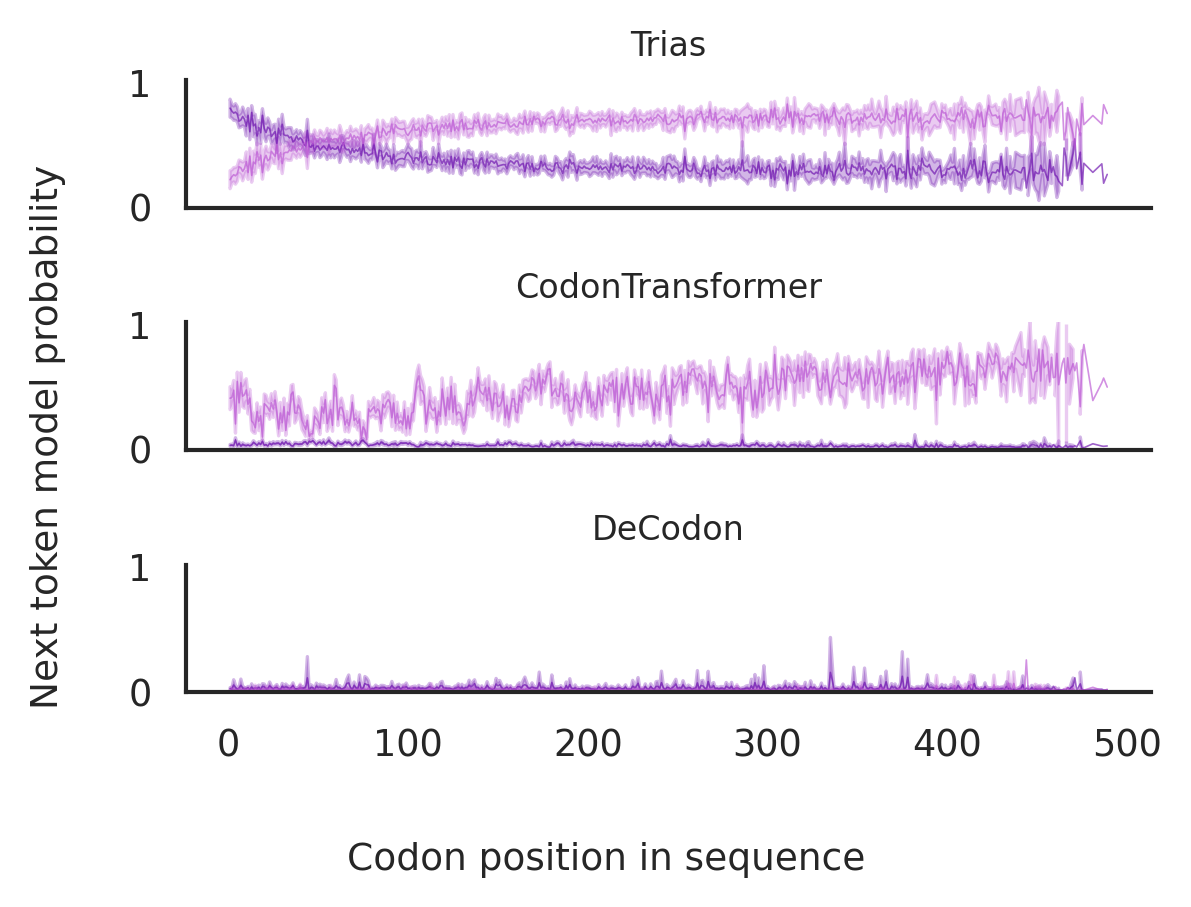

In [74]:
custom_palette = sns.color_palette(["#6a0dad","#ba55d3"])
target_aa = "Q"  
model_order = ["Trias", "CodonTransformer", "DeCodon"]

fig, axes = plt.subplots(3, 1, figsize=(4, 3), sharex=True, sharey=True, dpi=300)

# Plot each model outcome
for i, model_name in enumerate(model_order):
    df_single_aa = df_results[
        (df_results["amino_acid"] == target_aa) &
        (df_results["model"] == model_name)
    ]
    grouped = df_single_aa.groupby(["strategy", "codon_position"])["probability"].agg(
        mean="mean",
        sem="sem"
    ).reset_index()
    
    # Add confidence intervals
    grouped["ci_upper"] = grouped["mean"] + 1.96 * grouped["sem"]
    grouped["ci_lower"] = grouped["mean"] - 1.96 * grouped["sem"]
    
    for strategy, color in zip(["highest", "lowest"], custom_palette):
        subset = grouped[grouped["strategy"] == strategy]
        axes[i].plot(subset["codon_position"], subset["mean"], 
                    color=color, alpha=0.65, linewidth=0.4)
        axes[i].fill_between(subset["codon_position"], 
                           subset["ci_lower"], subset["ci_upper"], 
                           color=color, alpha=0.3)

    axes[i].set_title(f"{model_name}", fontsize=8)
    axes[i].set_ylim(-0.01, 1.01)
    if i < 2:
        axes[i].set_xlabel('')

fig.supxlabel("Codon position in sequence", fontsize=9)
fig.supylabel("Next token model probability", fontsize=9)
plt.tight_layout()
sns.despine()
plt.savefig(FIGURE_DIR+"figure_3F_alt.pdf", format="pdf")
plt.show()

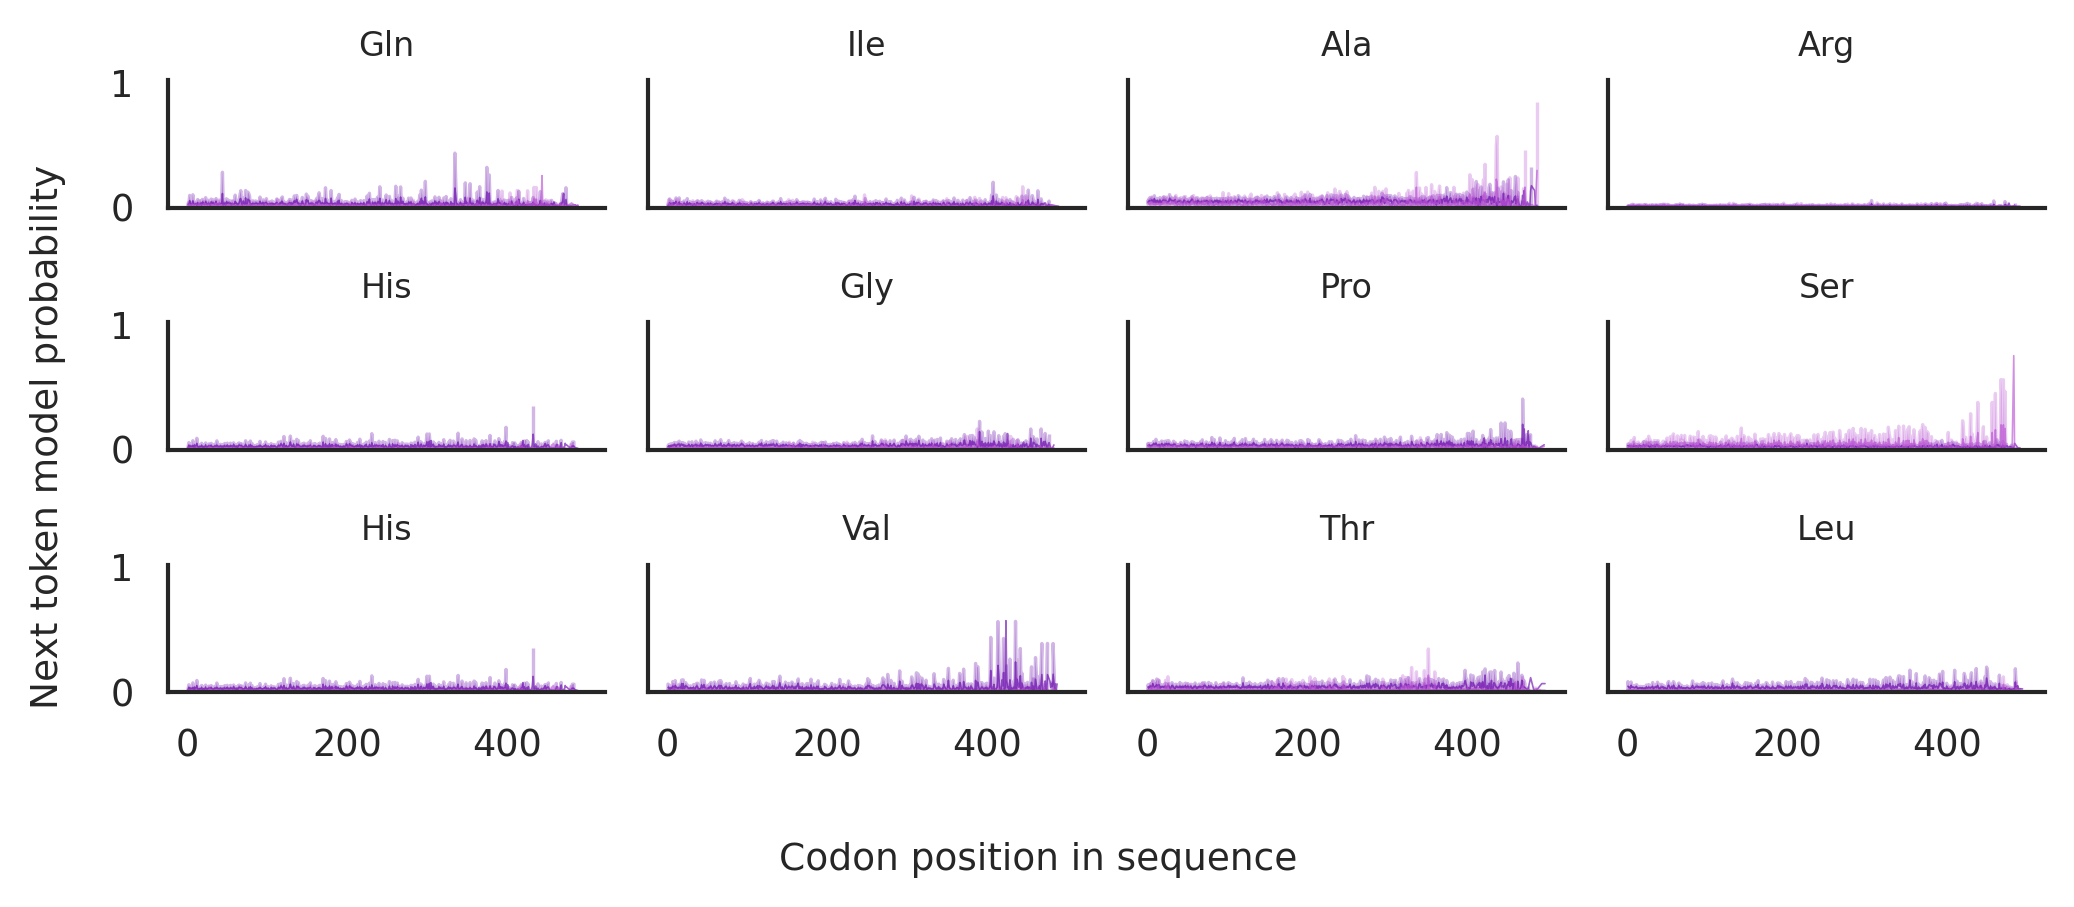

In [ ]:
custom_palette = sns.color_palette(["#6a0dad","#ba55d3"])
SELECTED_AMINO_ACIDS_1L = ['Q', 'I', 'A', 'R',
                           'H', 'G', 'P', 'S',
                           'H', 'V', 'T', 'L']
SELECTED_MODEL = "Trias" 

fig, axes = plt.subplots(3, 4, figsize=(7, 3), sharex=True, sharey=True, dpi=300)
axes = axes.flatten() 

# Plot each amino acid
for i, aa in enumerate(SELECTED_AMINO_ACIDS_1L):
    # Filter and group data
    df_aa = df_results[
        (df_results["amino_acid"] == aa) &
        (df_results["model"] == SELECTED_MODEL)
    ]
    grouped = df_aa.groupby(["strategy", "codon_position"])["probability"].agg(
        mean="mean",
        sem="sem"
    ).reset_index()
    
    # Add confidence intervals
    grouped["ci_upper"] = grouped["mean"] + 1.96 * grouped["sem"]
    grouped["ci_lower"] = grouped["mean"] - 1.96 * grouped["sem"]
    
    for strategy, color in zip(["highest", "lowest"], custom_palette):
        subset = grouped[grouped["strategy"] == strategy]
        axes[i].plot(subset["codon_position"], subset["mean"], 
                    color=color, alpha=0.65, linewidth=0.4)
        axes[i].fill_between(subset["codon_position"], 
                           subset["ci_lower"], subset["ci_upper"], 
                           color=color, alpha=0.3)

    axes[i].set_title(f"{one_to_three_letter[aa]}", fontsize=8)
    axes[i].set_ylim(-0.01, 1.01)
    if i < 2:
        axes[i].set_xlabel('')

fig.supxlabel("Codon position in sequence", fontsize=9)
fig.supylabel("Next token model probability", fontsize=9)
plt.tight_layout()
sns.despine()
plt.savefig(FIGURE_DIR+"figure_3F_supp_decodon.pdf", format="pdf")
plt.show()

# Figure 5 : Benchmarking against other codon optimization tools

In [56]:
gfp_seqs = gfp_data["Coding sequence"].str.replace('U', 'T').tolist()
gfp_protein_seq = str(Seq(gfp_seqs[0]).translate()) + '*'
gfp_prompt = ">>Homo sapiens<< " + gfp_protein_seq

In [ ]:
sp = "Homo sapiens"
sp_id = 9606
y_gfp_trias   = trias_score(gfp_seqs, sp, model, tokenizer, device)
y_gfp_codontx = codontx_score(gfp_seqs, sp, model_codontx, tokenizer_codontx, device)
y_gfp_decodon = decodon_score(gfp_seqs, model_decodon, taxid=sp_id, device=device)

gfp_data["trias_score"] = y_gfp_trias
gfp_data["codontx_score"] = y_gfp_codontx
gfp_data["decodon_score"] = y_gfp_decodon

In [49]:
trias_beam_ids, _ = generate_sequence(model, tokenizer, gfp_prompt, max_length=300, device=device, num_beams=20, do_sample=False)   
trias_greedy_ids, _ = generate_sequence(model, tokenizer, gfp_prompt, max_length=300, device=device, do_sample=False)   
trias_nucleus_ids, _ = generate_sequence(model, tokenizer, gfp_prompt, max_length=300, device=device, top_p=0.9, do_sample=True)  

In [50]:
genscript_gfp_seq = "ATGGTGTCCAAGGGCGAAGAACTGTTTACCGGCGTTGTGCCCATCCTGGTGGAACTGGACGGCGACGTGAATGGCCACAAGTTCAGCGTGTCTGGCGAGGGCGAGGGCGACGCCACATACGGCAAGCTGACCCTGAAATTCATCTGCACCACCGGCAAACTGCCAGTGCCATGGCCCACCCTTGTGACCACACTCACCTACGGCGTGCAATGTTTTAGCCGGTACCCCGACCACATGAAACAGCACGACTTCTTCAAGTCCGCCATGCCTGAGGGATATGTGCAGGAGCGGACCATCTTCTTTAAGGATGATGGAAATTACAAGACAAGAGCCGAAGTGAAGTTCGAGGGCGACACACTGGTCAACAGAATCGAGCTGAAGGGCATCGACTTCAAAGAGGACGGCAACATCCTGGGACATAAGCTGGAATACAACTACAACAGCCACAATGTGTACATCATGGCCGATAAGCAGAAGAACGGCATTAAGGTGAACTTCAAGATCAGGCACAACATCGAAGATGGCAGCGTGCAGCTGGCCGACCACTACCAGCAGAACACCCCTATCGGCGATGGACCTGTGCTGCTGCCTGACAACCACTACCTGTCTACACAGTCTGCTCTGAGCAAGGACCCCAACGAGAAGCGGGACCACATGGTCCTGCTGGAATTCGTGACAGCCGCCGGAATCACCCTGGGCATGGATGAGCTGTACAAGAGAAGCAGAGATATCAGCCACGGCTTCCCTCCTGCCGTGGCCGCTCAGGACGACGGCACCCTGCCTATGAGCTGCGCCCAAGAGAGCGGCATGGACAGACACCCTGCTGCCTGCGCCAGCGCCAGAATCAACGTGTGA"
idt_gfp_seq =       "ATGGTTAGTAAAGGGGAAGAATTGTTTACAGGCGTAGTGCCTATATTGGTTGAGCTGGACGGTGATGTAAACGGGCATAAGTTCTCCGTCAGCGGTGAAGGCGAGGGAGATGCCACTTATGGAAAATTGACATTGAAATTTATCTGCACAACAGGGAAGCTGCCCGTGCCGTGGCCCACTTTGGTTACAACACTCACATACGGCGTGCAATGTTTCTCTCGGTATCCCGACCACATGAAACAGCATGACTTTTTCAAAAGTGCGATGCCTGAAGGATACGTGCAAGAACGGACCATCTTCTTTAAAGACGACGGTAATTATAAGACAAGAGCAGAAGTTAAGTTCGAAGGAGATACACTTGTCAACAGGATAGAGCTGAAGGGGATTGATTTTAAGGAGGACGGCAATATATTGGGTCACAAACTCGAGTATAATTATAATTCACATAACGTCTATATAATGGCGGACAAGCAGAAGAATGGGATTAAAGTTAATTTCAAGATCAGACATAATATAGAAGATGGAAGTGTACAACTGGCCGACCATTATCAGCAGAATACTCCGATTGGGGACGGACCCGTCCTTCTGCCAGATAACCACTATCTCTCAACCCAGTCAGCTCTTAGCAAGGATCCAAACGAGAAGCGAGATCACATGGTACTTTTGGAATTTGTCACTGCAGCTGGCATCACCCTGGGGATGGACGAACTTTATAAGCGCAGCCGCGATATTAGCCATGGATTTCCCCCGGCTGTCGCAGCCCAGGATGATGGCACGCTTCCCATGTCATGTGCGCAGGAGAGCGGTATGGATAGACACCCAGCGGCCTGTGCCTCCGCGAGGATTAACGTCTAG"
twist_gfp_seq =     "ATGGTGTCTAAAGGAGAGGAGCTGTTCACTGGAGTAGTGCCCATATTGGTGGAGCTTGATGGGGACGTCAATGGCCATAAGTTCAGCGTGTCTGGCGAGGGCGAGGGAGATGCAACTTACGGAAAACTCACATTGAAATTCATCTGCACTACCGGAAAGCTTCCAGTGCCGTGGCCCACGCTGGTGACGACCCTCACTTACGGTGTTCAGTGTTTTTCCCGGTATCCAGACCACATGAAGCAGCACGACTTTTTCAAAAGTGCAATGCCAGAAGGTTACGTTCAAGAAAGGACCATCTTTTTTAAAGATGACGGGAATTACAAGACCCGGGCCGAAGTCAAGTTCGAAGGCGATACACTTGTGAATAGAATCGAGCTGAAAGGGATCGACTTTAAGGAGGACGGCAACATCCTGGGACATAAGCTGGAATATAATTATAACTCTCATAATGTCTATATTATGGCCGACAAGCAGAAGAATGGTATTAAGGTGAATTTTAAGATCCGACACAACATAGAGGATGGTAGCGTCCAATTGGCGGATCATTACCAGCAGAACACACCCATTGGCGACGGGCCGGTGCTCCTGCCAGATAACCACTATCTGTCAACCCAGTCCGCCCTCAGCAAAGACCCCAACGAGAAACGCGACCACATGGTACTGCTGGAATTCGTGACAGCTGCAGGCATCACACTCGGGATGGATGAGCTGTACAAACGATCCAGGGACATTTCCCATGGGTTCCCTCCTGCCGTTGCTGCTCAAGATGACGGCACCCTCCCTATGTCATGTGCGCAGGAAAGTGGCATGGATAGACACCCTGCAGCCTGCGCTAGCGCCCGCATTAACGTCTAG"

In [51]:
generated_gfp_seqs = {'trias_beam': tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(trias_beam_ids, skip_special_tokens=True)),
                      'trias_greedy': tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(trias_greedy_ids, skip_special_tokens=True)), 
                      'trias_nucleus': tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(trias_nucleus_ids, skip_special_tokens=True)), 
                      'random_bfc': baseline_predictor(tokenizer, gfp_protein_seq, 'Homo sapiens', rel_codon_count, mode="sample"), 
                      'random_urc': baseline_predictor(tokenizer, gfp_protein_seq, 'Homo sapiens', rel_codon_count, mode="uniform"),
                      'genscript': genscript_gfp_seq,
                      'twist': twist_gfp_seq,
                      'idt': idt_gfp_seq}

In [ ]:
scores = {}
for name, seq in generated_gfp_seqs.items():
    scores[name] = trias_score([seq], "Homo sapiens", model, tokenizer, device)[0]

In [53]:
scores

{'trias_beam': 0.7907871059036633,
 'trias_greedy': 0.7705958575775509,
 'trias_nucleus': 0.4116104679218624,
 'random_bfc': 0.3190111562202704,
 'random_urc': 0.2909677930393904,
 'genscript': 0.40216387700521117,
 'twist': 0.3335710265913808,
 'idt': 0.3154901952736147}

In [ ]:
metrics = ["AUC expression (HEK293)", "half-life (HEK293)"]
labels = ["Total fluorescence (AUC)", "mRNA half-life (hours)"]

score_cols = {
    "Trias": "trias_score",
    "CodonTransformer": "codontx_score",
    "DeCodon": "decodon_score",
}

ordered_classes = ["High_sRSCU_high_struc",
                   "High_sRSCU_mid_struc",
                   "Mid_sRSCU_high_struc",
                   "Mid_sRSCU_mid_struc",
                   "Mid_sRSCU_low_struc",
                   "Low_sRSCU_low_struc"]
palette = sns.color_palette("viridis", n_colors=6)
class_colors = dict(zip(ordered_classes, palette))


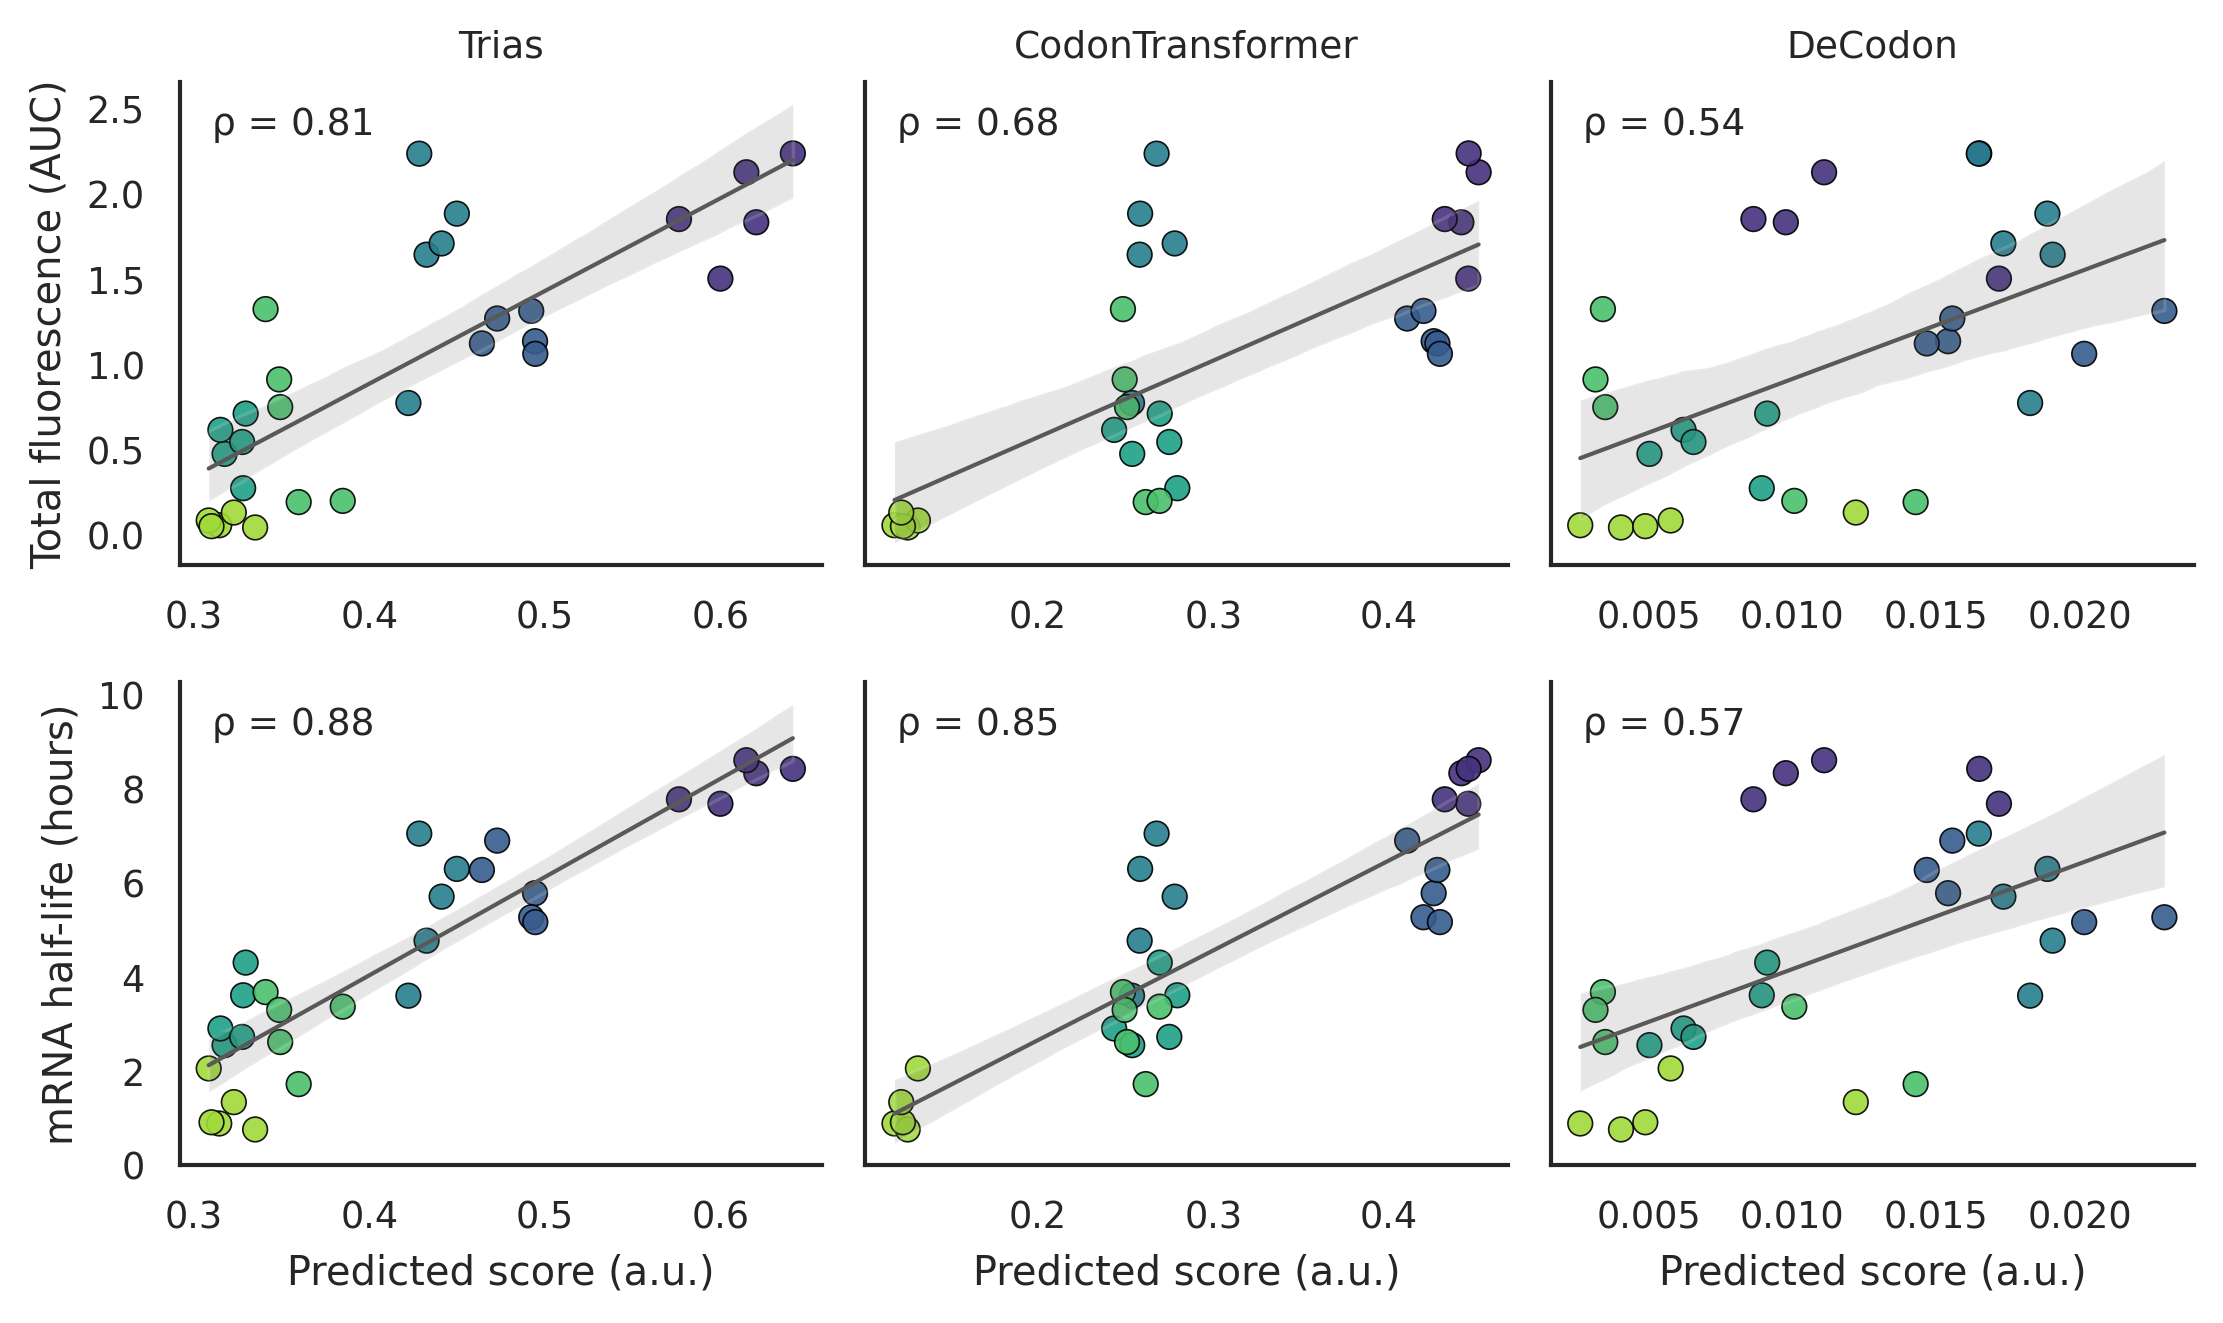

In [76]:
# 2 metrics (rows) × 3 models (cols)
fig, axes = plt.subplots(
    len(metrics), len(score_cols),
    figsize=(7.5, 4.5), dpi=300, sharey="row"
)

for row_i, metric in enumerate(metrics):
    for col_i, (model_name, score_col) in enumerate(score_cols.items()):
        ax = axes[row_i, col_i]
        x_vals = gfp_data[score_col]

        sns.scatterplot(
            data=gfp_data,
            x=score_col,
            y=metric,
            hue="sequence class",
            palette=class_colors,
            ax=ax,
            edgecolor="black",
            linewidth=0.4,
            legend=False,
            alpha=0.9,
            s=35,
        )

        sns.regplot(
            x=x_vals, y=gfp_data[metric],
            ax=ax, scatter=False,
            color='0.35', line_kws={"linewidth": 1}
        )

        rho, pval = spearmanr(x_vals, gfp_data[metric])
        ax.text(
            0.05, 0.95,
            f"ρ = {rho:.2f}",
            transform=ax.transAxes,
            fontsize=9,
            horizontalalignment='left',
            verticalalignment='top',
        )

        # Column title only on top row
        if row_i == 0:
            ax.set_title(model_name, fontsize=9)

        # Y-label only on first column
        if col_i == 0:
            ax.set_ylabel(labels[row_i])
        else:
            ax.set_ylabel("")

        # X-label only on bottom row
        if row_i == len(metrics) - 1:
            ax.set_xlabel("Predicted score (a.u.)")
        else:
            ax.set_xlabel("")

sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR + "figure_4A_alt.pdf",
             format="pdf", bbox_inches="tight")
plt.show()

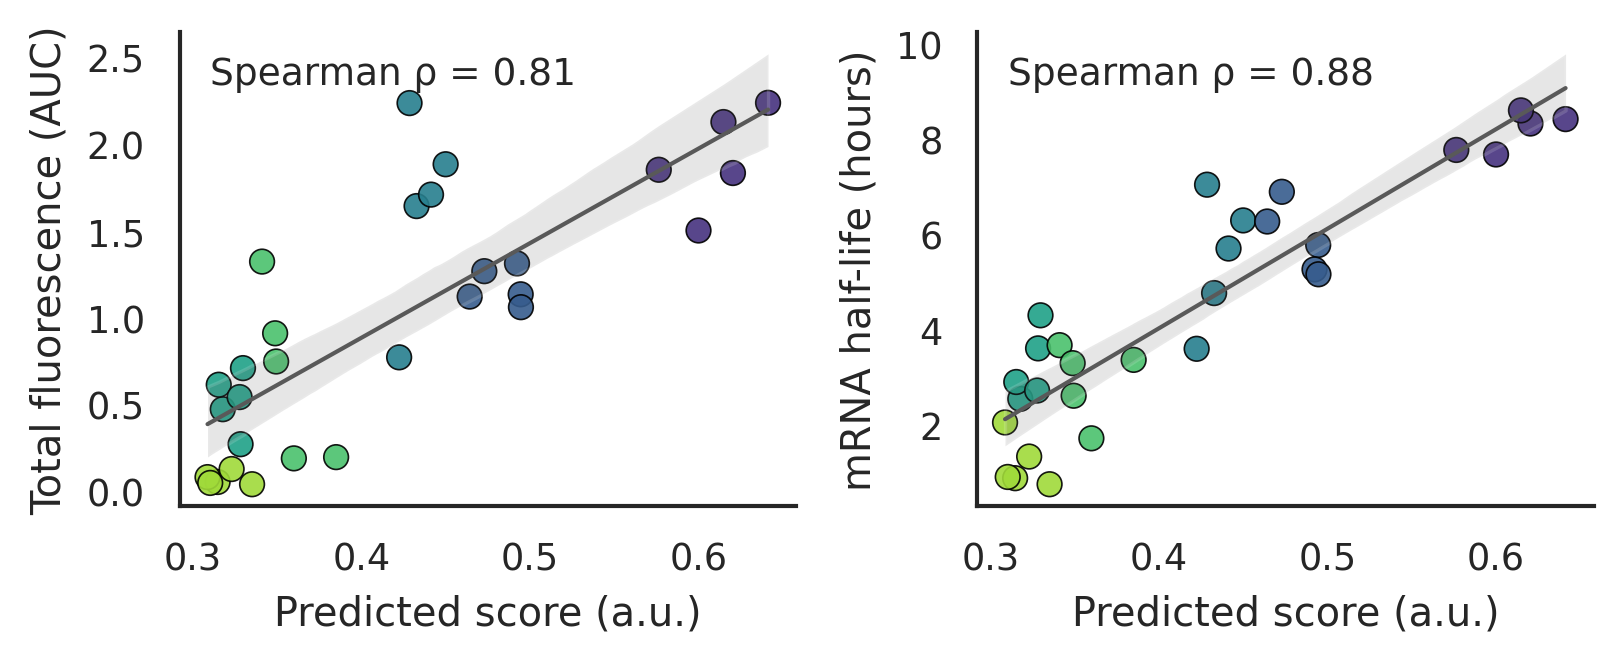

In [77]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.3), dpi=300)
axes = axes.flatten()

# Create scatter plots for each metric
for i, metric in enumerate(metrics):
    sns.scatterplot(
        data=gfp_data,
        x='trias_score',
        y=metric,
        hue="sequence class",
        palette=class_colors,
        ax=axes[i],
        edgecolor="black",
        linewidth=0.4,
        legend=False,
        alpha=0.9,
        s=35,
    )

    # Regression line (same for all)
    sns.regplot(
        x=y_gfp, y=gfp_data[metric],
        ax=axes[i], scatter=False,
        color='0.35', line_kws={"linewidth": 1}
    )

    # Spearman correlation
    rho, pval = spearmanr(y_gfp, gfp_data[metric])
    axes[i].text(
        0.05, 0.95,
        f"Spearman ρ = {rho:.2f}",
        transform=axes[i].transAxes,
        fontsize=9,
        horizontalalignment='left',
        verticalalignment='top'
    )

    axes[i].set_ylabel(labels[i])
    axes[i].set_xlabel("Predicted score (a.u.)")

sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_4A.pdf", format="pdf")
plt.show()


In [146]:
# Define window size
window_size = 18

# Sort GFP sequences by expression (highest first)
sorted_idx = np.argsort(gfp_data["AUC expression (HEK293)"].values)[::-1]
gfp_seqs_sorted = [gfp_seqs[i] for i in sorted_idx]

# Extract all GFP codon sequences
gfp_codon_seqs = {f"GFP Variant {i+1}": [gfp_seqs[idx][j:j+3] for j in range(0, len(gfp_seqs[idx]), 3)] + ['TGA']
                   for i, idx in enumerate(range(len(gfp_seqs)))}

# Compute min/max profiles for all GFP sequences
gfp_min_max_profiles = {name: calculate_min_max(seq, abs_codon_count_dict, codon_to_aa, window_size)
                        for name, seq in gfp_codon_seqs.items()}

# Compute min/max profile for Trias only
trias_codons = [trias_greedy_seq[i:i+3] for i in range(0, len(trias_greedy_seq), 3)]
trias_min_max = calculate_min_max(trias_codons, abs_codon_count_dict, codon_to_aa, window_size)

In [163]:
len(trias_min_max)

268

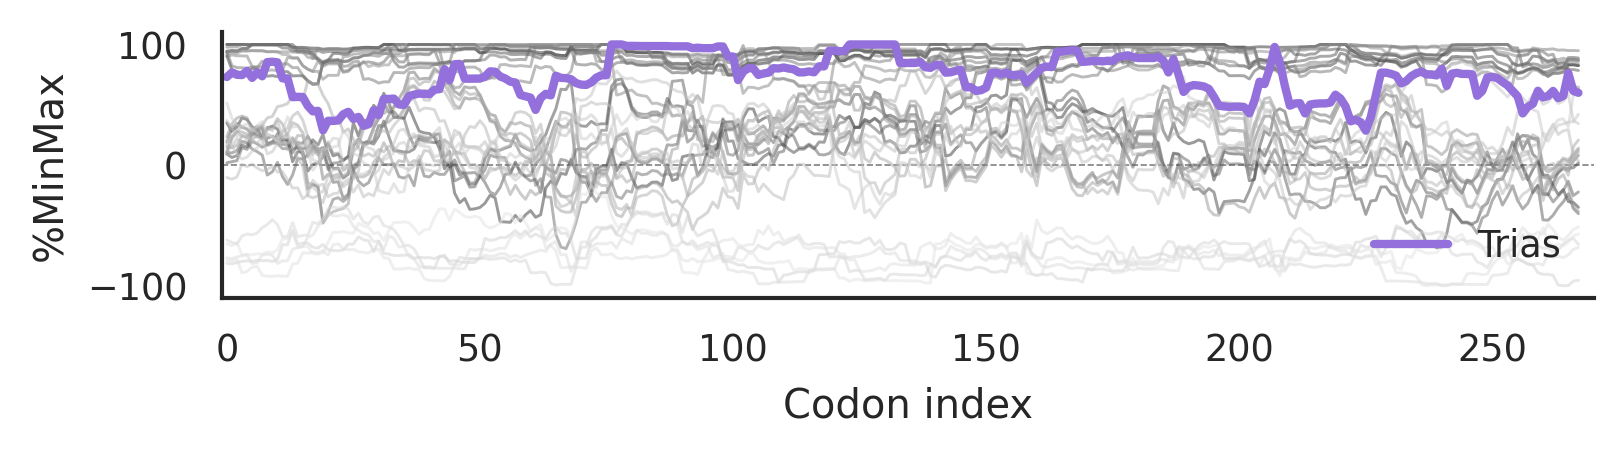

In [166]:
fig, ax = plt.subplots(figsize=(5.5, 1.6), dpi=300)

# Gray ramp: darkest for highest-expression variant (first in sorted list)
n_variants = len(gfp_min_max_profiles)
gray_cmap = plt.cm.Greys
gray_colors = [gray_cmap(0.85 - 0.65 * (i / (n_variants - 1))) for i in range(n_variants)]

# Plot the 30 GFP variants in the background
for i, (name, profile) in enumerate(gfp_min_max_profiles.items()):
    ax.plot(profile, color=gray_colors[i], linewidth=0.7, alpha=0.5)

# Plot Trias on top
ax.plot(trias_min_max, color="mediumpurple", linewidth=2, label="Trias")

ax.set_xlabel("Codon index")
ax.set_ylabel("%MinMax")
ax.set_xlim(-1, 270)
ax.axhline(0, color="0.5", linestyle="--", linewidth=0.4, zorder=0)
ax.legend(frameon=False, loc="lower right")
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_4B.pdf", format="pdf")
plt.show()

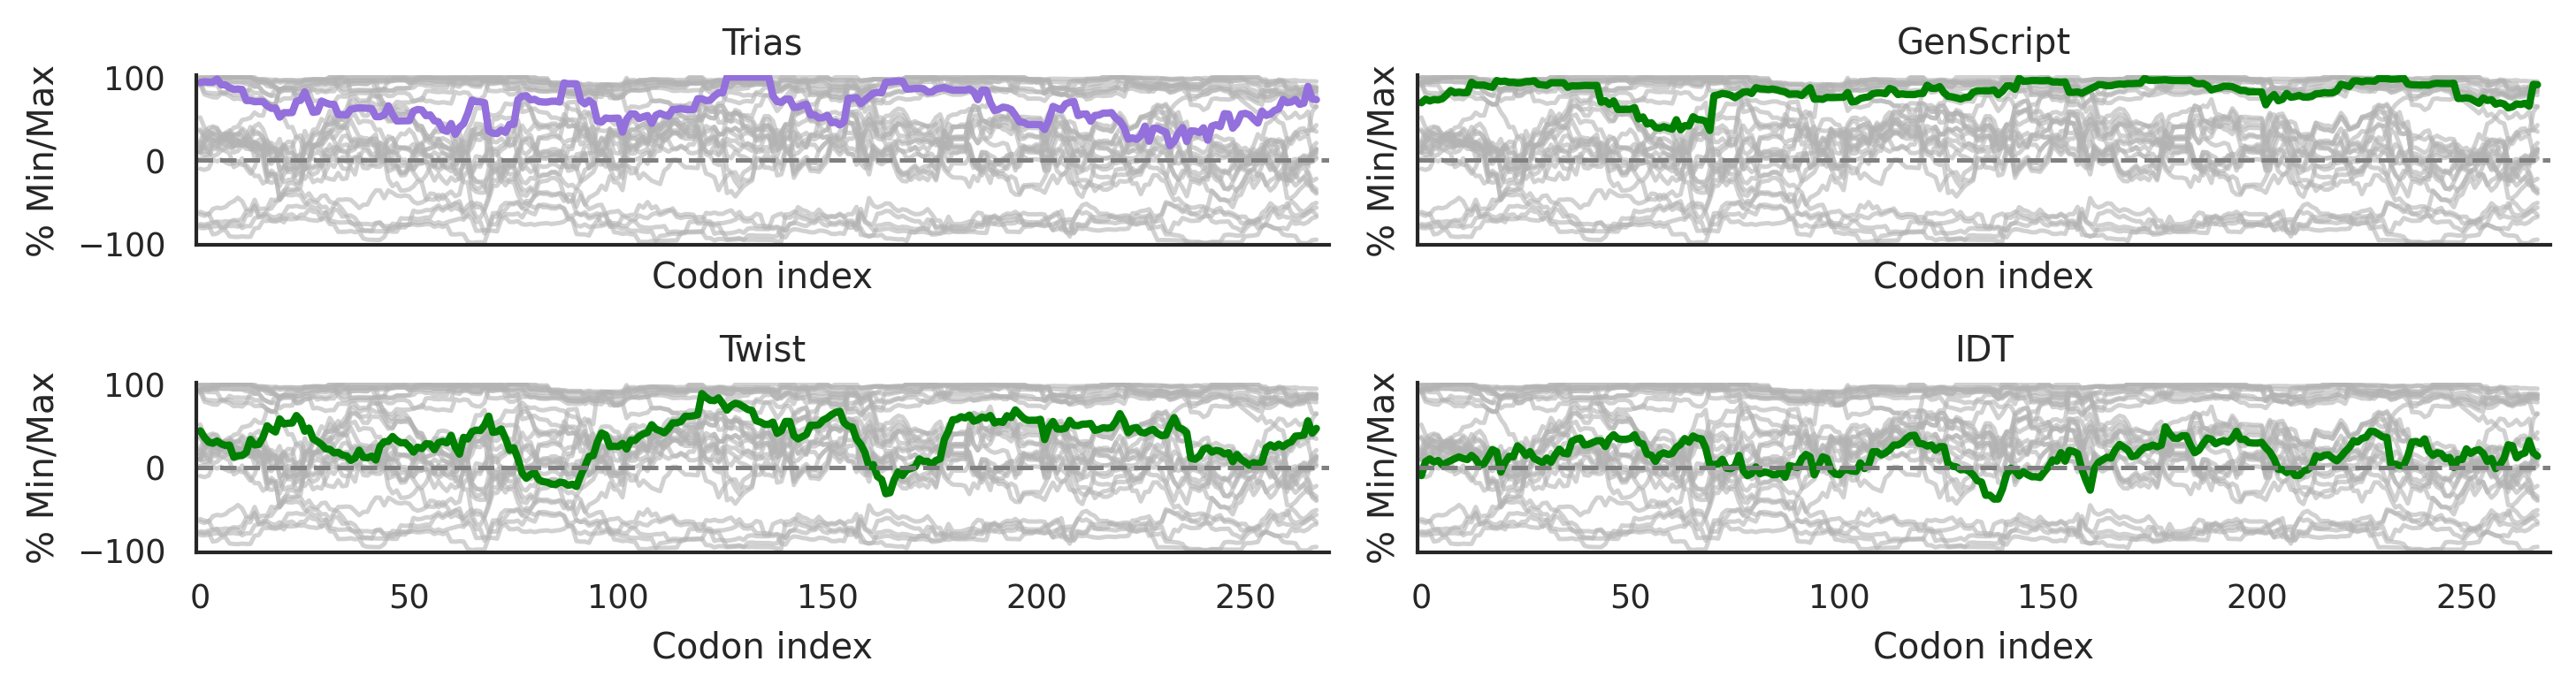

In [97]:
# Define colors for different categories
gfp_colors = sns.color_palette("Greys", n_colors=len(gfp_min_max_profiles))
color_palette = [str(x) for x in np.linspace(0.8, 0.2, 6)]
colors = [color_palette[j // 5] for j in range(len(y_gfp))]
synthetic_order = ["Trias", "GenScript", "Twist", "IDT"]

fig, axes = plt.subplots(2, 2, figsize=(9.8, 2.7), sharex=True, sharey=True, dpi=300)
for ax, synthetic_name in zip(axes.flat, synthetic_order):
    codon_indices = list(range(len(next(iter(gfp_min_max_profiles.values())))))
    # Plot selected GFP sequences (subset if necessary)
    for i, (name, profile) in enumerate(list(gfp_min_max_profiles.items())):
        ax.plot(codon_indices, profile, color='0.7', alpha=0.6, label=name) #
    # Plot the specific synthetic sequence in its designated panel
    color = 'mediumpurple' if synthetic_name == "Trias" else 'green'
    ax.plot(codon_indices, synthetic_min_max_profiles[synthetic_name], color=color, alpha=1, linewidth=2, label=synthetic_name)

    ax.axhline(0, color='0.5', linestyle='--')
    ax.set_title(synthetic_name)
    ax.set_xlim(-1, 270)
    ax.set_ylim(-102, 102)
    ax.set_xlabel("Codon index")
    ax.set_ylabel("% Min/Max")
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_5B.pdf", format="pdf")
plt.show()

In [98]:
gfp_df = gfp_data[['Unnamed: 0', 'sequence class', 'Coding sequence']+metrics].copy()
gfp_df.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)
gfp_df['trias_score'] = y_gfp
gfp_df['Coding sequence'] = gfp_df['Coding sequence'].str.replace('U', 'T') + 'TGA'
sources = ['trias', 'idt', 'twist', 'genscript']
ref_seqs = {source: globals()[f'{source}_gfp_seq'] for source in sources}

In [99]:
# Codon similarities and euclidean distance scores 
for source in sources:
    gfp_df[f'codon_similarity_{source}'] = gfp_df['Coding sequence'].apply(
        lambda seq: sequence_similarity(ref_seqs[source], seq, sequence_type='codon')
    )
    ref_codons = seq_to_codons(ref_seqs[source])
    ref_min_max = calculate_min_max(ref_codons, abs_codon_count_dict, codon_to_aa, 18)
    gfp_df[f'euclidean_{source}'] = gfp_df['Coding sequence'].apply(
        lambda seq: euclidean(calculate_min_max(seq_to_codons(seq), abs_codon_count_dict, codon_to_aa, 18), ref_min_max)/(len(seq)/3)
    )

In [100]:
# Get indices of 3 highest and 3 lowest expression sequences
highest_expr_idx = gfp_df.nlargest(5, 'AUC expression (HEK293)').index
lowest_expr_idx = gfp_df.nsmallest(5, 'AUC expression (HEK293)').index

# Calculate averages for each metric and company
sources = ['trias', 'genscript', 'twist', 'idt']
averages = {
    'codon_similarity': {
        'high': [],
        'low': []
    },
    'euclidean': {
        'high': [],
        'low': []
    }
}

# Calculate averages
for source in sources:
    # Codon similarity averages
    averages['codon_similarity']['high'].append(
        gfp_df.loc[highest_expr_idx, f'codon_similarity_{source}'].mean()
    )
    averages['codon_similarity']['low'].append(
        gfp_df.loc[lowest_expr_idx, f'codon_similarity_{source}'].mean()
    )
    
    # DTW averages
    averages['euclidean']['high'].append(
        gfp_df.loc[highest_expr_idx, f'euclidean_{source}'].mean()
    )
    averages['euclidean']['low'].append(
        gfp_df.loc[lowest_expr_idx, f'euclidean_{source}'].mean()
    )
    

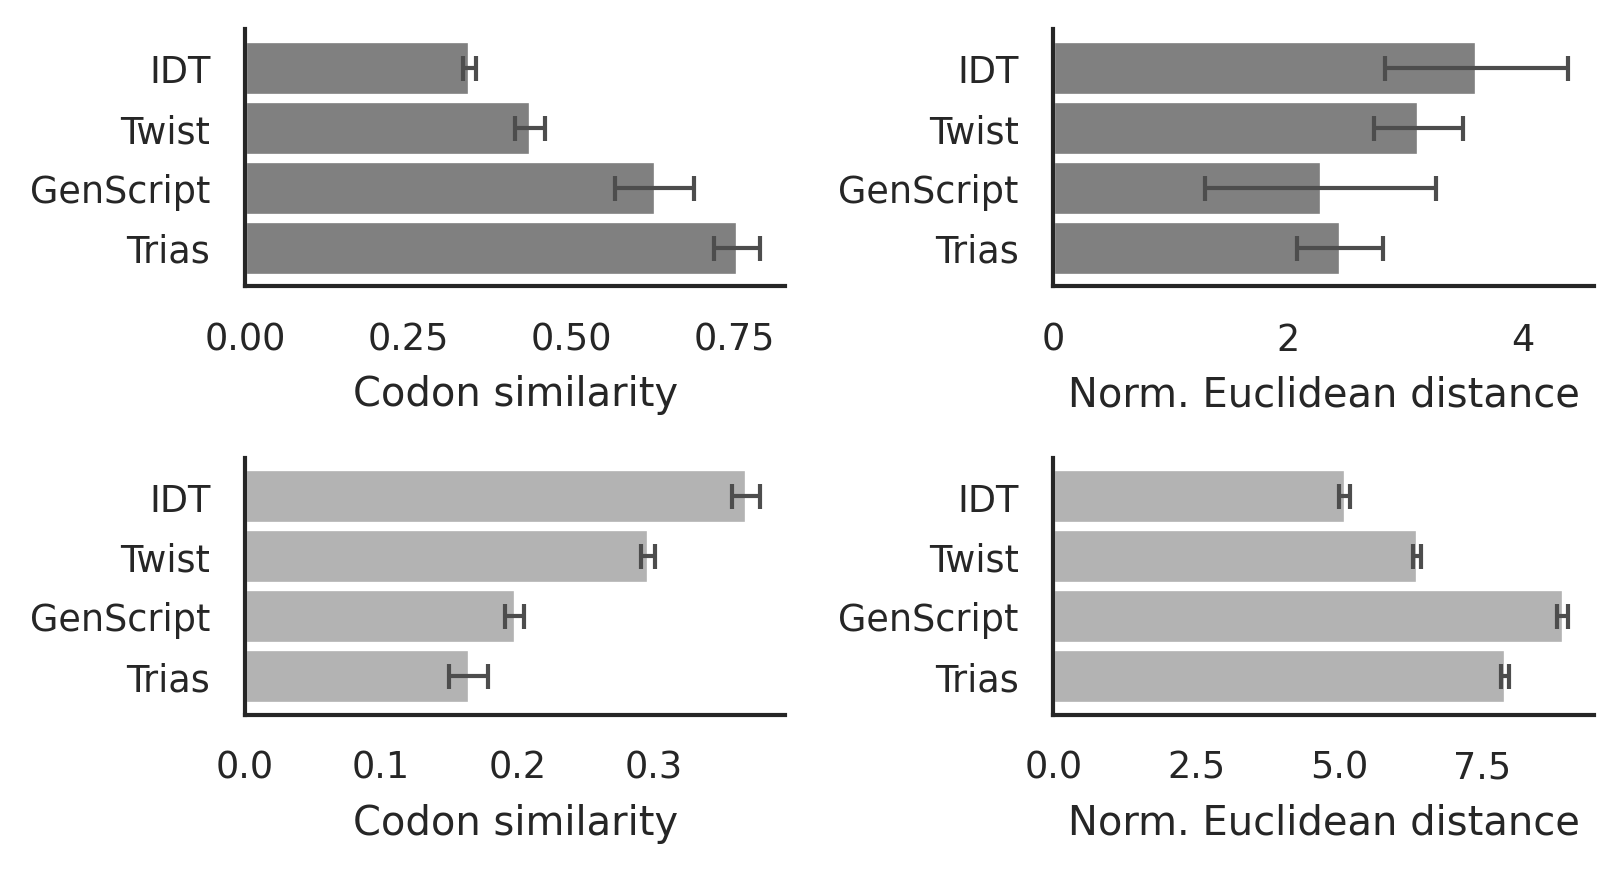

In [101]:
# Setup
fig, axes = plt.subplots(2, 2, figsize=(5.5, 3), dpi=300)
height = 0.9
labels = ['Trias', 'GenScript', 'Twist', 'IDT']  # Reverse order for display
y = np.arange(len(sources))  # Reverse y positions

# Calculate standard errors
se_dict = {
    'codon_high': [gfp_df.loc[highest_expr_idx, f'codon_similarity_{s}'].std() / np.sqrt(3) for s in sources],
    'codon_low': [gfp_df.loc[lowest_expr_idx, f'codon_similarity_{s}'].std() / np.sqrt(3) for s in sources],
    'euclidean_high': [gfp_df.loc[highest_expr_idx, f'euclidean_{s}'].std() / np.sqrt(3) for s in sources],
    'euclidean_low': [gfp_df.loc[lowest_expr_idx, f'euclidean_{s}'].std() / np.sqrt(3) for s in sources]
}

# Plot configurations
plot_configs = [
    {'data': averages['codon_similarity']['high'], 'err': se_dict['codon_high'], 'xlabel': 'Codon similarity'},
    {'data': averages['euclidean']['high'], 'err': se_dict['euclidean_high'], 'xlabel': 'Norm. Euclidean distance'},
    {'data': averages['codon_similarity']['low'], 'err': se_dict['codon_low'], 'xlabel': 'Codon similarity'},
    {'data': averages['euclidean']['low'], 'err': se_dict['euclidean_low'], 'xlabel': 'Norm. Euclidean distance'}
]

# Create plots
for ax, config in zip(axes.flat, plot_configs):
    ax.barh(y, config['data'], height,
            xerr=config['err'],
            error_kw={'ecolor': '0.3', 'capsize': 3, 'capthick': 1, 'elinewidth': 1},
            color='0.5' if ax in axes[0] else '0.7')
    ax.set_xlabel(config['xlabel'])
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_5C.pdf", format="pdf")
plt.show()

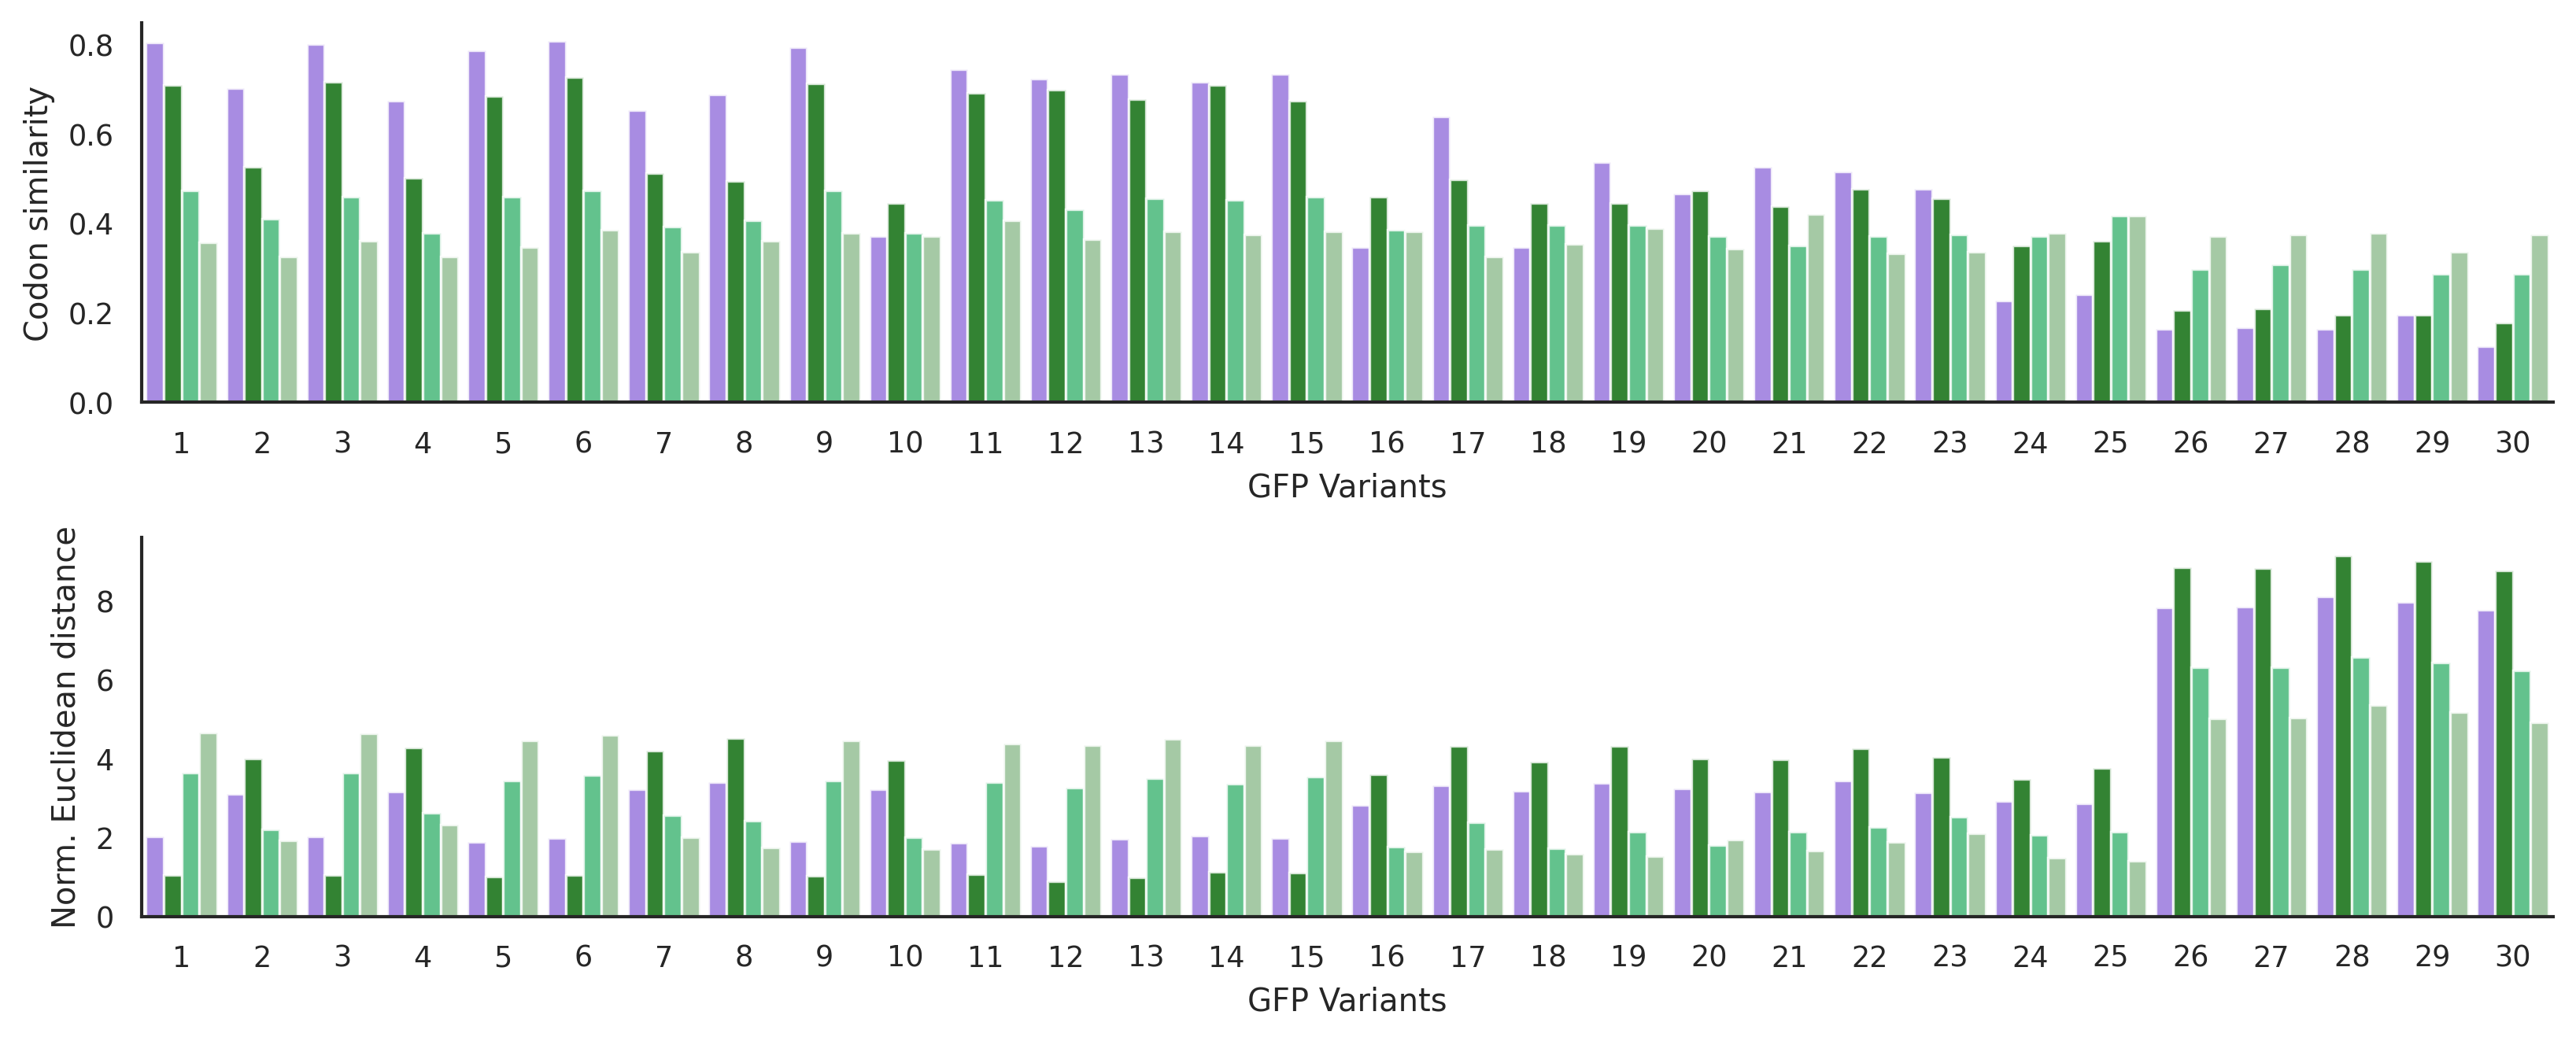

In [102]:
# Sort and label variants
sorted_df = gfp_df.sort_values('AUC expression (HEK293)', ascending=False)
variant_numbers = range(1, len(sorted_df) + 1)
x = np.arange(len(sorted_df))
width = 0.221
# Colors and offsets
colors = ['mediumpurple', 'darkgreen', 'mediumseagreen', 'darkseagreen']
source_offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

# Plot settings
metrics = ['codon_similarity', 'euclidean']
ylabels = ['Codon similarity', 'Norm. Euclidean distance']

fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), dpi=300)
for ax, metric, ylabel in zip(axes, metrics, ylabels):
    all_values = []

    for idx, source in enumerate(sources):
        values = sorted_df[f'{metric}_{source}']
        all_values.append(values)

        ax.bar(x + source_offsets[idx], values, width,
               label=source.capitalize(),
               color=colors[idx], alpha=0.8)
        
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(variant_numbers)
    ax.set_xlabel('GFP Variants')
    ax.set_xlim(-0.5, 29.5) 

sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR+"figure_S11_A_B.pdf", format="pdf")
plt.show()
